# Table of Content

- [Table of Content](#table-of-content)


# 0 - General
[Back to Table of Content](#table-of-content)

# High Resolution Joint Symbolic Dynamics Reveal Altered Cardiorespiratory Network Pathways and Autonomic Dysregulation in Schizophrenia and Depression

## Introduction
[Back to Table of Content](#table-of-content)

This project investigates autonomic regulation and cardiorespiratory network dynamics in patients with depression and schizophrenia using high resolution joint symbolic dynamics, HRJSD, and related heart rate variability and respiratory coupling measures.
The study includes two clinical cohorts. The depression cohort consists of healthy controls, unmedicated patients with depression, and patients receiving antidepressant medication. The schizophrenia cohort consists of a separate healthy control group and patients with schizophrenia.
The main purpose of this project is to identify group differences in autonomic and cardiorespiratory regulation across psychiatric conditions and treatment groups. Particular focus is placed on directional coupling between heart rate and respiration, complexity of cardiorespiratory dynamics, and measures of parasympathetic activity.

## Abbreviations and group labels
[Back to Table of Content](#table-of-content)

Study groups

* KON1 = healthy control group for the depression cohort
* DEP = unmedicated depression group
* DEP1 = depression group treated with SSRI medication
* DEP2 = depression group treated with SNRI medication
* KON2 = healthy control group for the schizophrenia cohort
* SCZ = schizophrenia group

Group coding

* 0 = KON1
* 1 = DEP
* 2 = DEP1
* 3 = DEP2
* 4 = KON2
* 5 = SCZ

Medication groups

* SSRI = selective serotonin reuptake inhibitor
* SNRI = serotonin norepinephrine reuptake inhibitor
* NaSSA = noradrenergic and specific serotonergic antidepressant
* NARI = norepinephrine reuptake inhibitor

Key physiological abbreviations

* BBI = beat to beat interval
* RESP = respiration
* HRV = heart rate variability
* pvRSA = peak valley respiratory sinus arrhythmia
* RMSSD = root mean square of successive differences
* sdNN = standard deviation of normal to normal intervals
* BF = breathing frequency
* NF = normalized coupling factor
* Se = symbolic entropy
* Area_BBI->RESP = directional influence from heart rate dynamics to respiration
* Area_RESP->BBI = directional influence from respiration to heart rate dynamics
* D_12n_tau0 = symbolic dynamics based coupling and complexity parameter at lag 0


## Study aims
[Back to Table of Content](#table-of-content)

The primary aim of this project is to compare cardiorespiratory network regulation between healthy controls and patients with depression or schizophrenia.

The secondary aims are to assess:
* differences between unmedicated and medicated depression groups
* potential effects of SSRI and SNRI treatment on autonomic regulation
* differences in directional coupling between cardiac and respiratory systems
* associations between symbolic dynamics parameters and established autonomic markers
* whether altered coupling patterns are shared across depression and schizophrenia or are disorder specific

## Analysis scope
[Back to Table of Content](#table-of-content)

This notebook covers the following analysis domains.

*Sample characteristics:* age; sex; BMI; smoking behavior; coffee intake; alcohol use; toxicology findings; medication status; medication class; medication dose equivalence; disease duration; age at first manifestation; symptom severity scores including BDI and HAMD; sleepiness ratings; heart rate; HRV parameters including sdNN and RMSSD.

*Depression cohort group comparisons:*

* KON1 versus DEP
* KON1 versus DEP1
* KON1 versus DEP2
* KON1 versus combined medicated depression groups DEP1 and DEP2
* KON1 versus all depression groups combined DEP, DEP1, and DEP2
* DEP versus DEP1
* DEP versus DEP2

*Schizophrenia cohort group comparisons:*
* KON2 versus SCZ

*Cardiorespiratory network parameters:* meanNN_BBI; sdNN_BBI; meanNN_RESPf; sdNN_RESPf; BF; inspiration time; expiration time; inspiration to expiration ratio; pvRSA; symbolic respiratory and cardiac pattern measures; HRJSD entropy measures; D_12n_tau0; NF; Se_BBI->RESP; Se_RESP->BBI; Area_BBI->RESP; Area_RESP->BBI.

*Correlation analyses:* correlations between D_12n_tau0 and pvRSA; NF; Area_BBI->RESP; Area_RESP->BBI; additional exploratory correlations between symbolic dynamics measures and classical HRV indices such as RMSSD and sdNN.

## Comparison structure
[Back to Table of Content](#table-of-content)

The analysis strategy follows the structure of the two cohorts.

*Depression cohort:*
* KON1 versus DEP
* KON1 versus DEP1
* KON1 versus DEP2
* KON1 versus DEP1 and DEP2 combined
* KON1 versus DEP, DEP1, and DEP2 combined
* DEP versus DEP1
* DEP versus DEP2

*Schizophrenia cohort:*
* KON2 versus SCZ

For selected analyses, additional combined group comparisons may be used to increase statistical power and to distinguish between disease related and medication related effects.

## Statistical approach
[Back to Table of Content](#table-of-content)

The main group comparisons will initially be performed using nonparametric two tailed Mann Whitney U tests because several physiological and symbolic dynamics parameters are expected to show non normal distributions and unequal variances across groups.

Results will primarily be presented as mean ± SD together with medians and interquartile ranges where appropriate. Exact p values, effect sizes, and corrected significance thresholds will be reported.

Given the large number of pairwise comparisons across autonomic and symbolic dynamics variables, correction for multiple testing will be applied using the Bonferroni Holm procedure.

Correlation analyses will be performed using Spearman rank correlations.

## Objective
[Back to Table of Content](#table-of-content)

The objective of this notebook is not only to reproduce the originally planned group comparisons, but also to provide a transparent and reproducible framework for exploring autonomic dysregulation, altered cardiorespiratory coupling, and potential medication effects across depression and schizophrenia.

## Methodological role
[Back to Table of Content](#table-of-content)

This notebook serves as the central reproducible record of:
* how raw study exports are cleaned and harmonised across sheets
* how clinical, physiological, and symbolic dynamics variables are defined and derived
* how depression and schizophrenia comparison groups are generated
* how nonparametric group comparisons and correlation analyses are implemented
* how multiple testing correction and effect size estimation are performed
* how tables and figures for the manuscript are generated reproducibly

## Planned manuscript wording for statistics
[Back to Table of Content](#table-of-content)

Significant differences between groups were estimated using nonparametric exact two tailed Mann Whitney U tests. Comparisons were performed between KON1 and DEP, DEP1, and DEP2, between DEP and medicated depression groups, and between KON2 and SCZ. Correlation analyses were performed using Spearman rank correlations. To account for multiple testing, p values were adjusted using the Bonferroni Holm procedure. Results are presented as mean ± SD, with medians and interquartile ranges additionally reported where appropriate.

## Acknowledgements
[Back to Table of Content](#table-of-content)

Statistical analysis and data preparation were conducted by **Dr. Steven Ngandeu Schepanski**, who also oversaw the development of this notebook.

# 0 - Setup
[Back to Table of Content](#table-of-content)

In [1]:
# =========================================================
# 0  Setup
# =========================================================

# I import the packages that I need for data handling, statistics, and figures
from pathlib import Path
import re
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=RuntimeWarning)

# I define the project paths
BASE_DIR = Path("/Users/stevenschepanski/Documents/04_ANALYSIS/SCZ_DEP")
DATA_PATH = BASE_DIR / "data" / "Parameter_SCZ-DEP.xlsx"
GRAPH_DIR = BASE_DIR / "graphs"

# I make sure that the graph output folder exists
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# I set some display options for easier inspection in the notebook
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [2]:
# =========================================================
# 1  Load the two sheets
# =========================================================

# I read both sheets from the Excel file
sheet1 = pd.read_excel(DATA_PATH, sheet_name=0)
sheet2 = pd.read_excel(DATA_PATH, sheet_name=1)

# I inspect the first rows
display(sheet1.head())
display(sheet2.head())

# I inspect the dimensions
print("sheet1 shape", sheet1.shape)
print("sheet2 shape", sheet2.shape)

,ID,Gruppe,Diagnose,Med.gruppe,Alter,Sex,Gewicht,Größe,Realschulabschluss_Sonderschule,Abitur,Raucher,Rauchverhalten,CO_vorher,CO_nachher,Kaffee,Tassen_pro_Tag,Alkohol,Toxikologie,aktueller_Drogenkonsum,BMI,SSRI,SNRI_NaSSA_NARI,Medikament,Äquivalenzdosis Berechnung,Kommentar,stationärer_Aufenthalt,Datum_der_Messung,Medieinnahme_Dauer_Tage,Erkrankungsdauer_aktuell,Vereinheitlichung_Erkrankungsdauer_aktuell_in_Wochen,Erstdiagnose_Datum,Erstdiagnose_Jahr,Erstmanifestation_Alter,Erkrankungsdauer_Jahre,Auffälligkeiten_Bewertung,Auffälligkeiten_Kommentar,Fehlsichtigkeit,Auge_links_dpt,Auge_rechts_dpt,Kommentar_Fehlsichtigkeit,BDI,ln_BDI,HAMD,ln_HAMD,GS,WM,RU,Epworth_Sleepiness_Scale,Schläfrigkeit_SSSvor,ln_Schläfrigkeit_vor,Schläfrigkeit_SSSnach,ln_Schläfrigkeit_nach,ID_A,mHR,sdNN,RMSSD
0,'D03,1,2,0,44,1,71.3,1.78,0,1,0,0.0,NaN,NaN,ja,1,1.0,nein,nein,22.503472,NaN,NaN,NaN,NaN,NaN,NaN,#NULL!,NaN,NaN,8.0,NaN,NaN,44.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,27.0,3.332205,37.0,3.610918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,'D03,99.701,33.172,9.5142
1,'D04,1,2,0,31,1,59.0,1.78,0,1,1,5.0,NaN,NaN,ja,3,1.0,nein,nein,18.621386,NaN,NaN,NaN,NaN,NaN,NaN,#NULL!,NaN,NaN,288.0,NaN,NaN,25.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,25.0,3.258097,27.0,3.295837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,'D04,70.664,81.905,59.0630
2,'D09,1,2,0,22,0,52.0,1.66,0,1,0,0.0,NaN,NaN,nein,0,0.0,nein,nein,18.870663,NaN,NaN,NaN,NaN,NaN,NaN,#NULL!,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,2.0,2.50,1.50,NaN,17.0,2.890372,22.0,3.091042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,'D09,87.558,40.914,29.1320
3,'D16,1,2,0,21,1,55.0,1.68,0,1,1,12.0,NaN,NaN,ja,2,0.0,nein,nein,19.486961,NaN,NaN,NaN,NaN,NaN,NaN,#NULL!,NaN,NaN,240.0,NaN,NaN,16.0,5.0,NaN,NaN,1.0,-3.50,-3.50,NaN,23.0,3.178054,28.0,3.332205,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,'D16,82.464,55.697,37.7440
4,'D20,1,2,0,45,0,75.0,1.75,0,1,0,0.0,NaN,NaN,nein,0,1.0,ja,nein,24.489796,NaN,NaN,NaN,NaN,NaN,NaN,#NULL!,NaN,NaN,0.0,NaN,NaN,45.0,0.0,NaN,NaN,2.0,1.75,2.25,NaN,32.0,3.496508,32.0,3.465736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,'D20,72.364,38.836,29.5500


,ID,Gruppe,meanNN_BBI,sdNN_BBI,meanNN_RESPf,sdNN_RESPf,BF,insp_time,exsp_time,insp-2-exsp,pvRSA,RESPf-E0_tau0,RESPf-E1_tau0,RESPf-E2_tau0,RESPf-LU1_tau0,RESPf-LD1_tau0,RESPf-LA1_tau0,RESPf-P_tau0,RESPf-V_tau0,BBI-E0_tau0,BBI-E1_tau0,BBI-E2_tau0,BBI-LU1_tau0,BBI-LD1_tau0,BBI-LA1_tau0,BBI-P_tau0,BBI-V_tau0,normHRJSDShannon_tau0,normHRJSDrenyi025_tau0,normHRJSDrenyi2_tau0,normHRJSDrenyi4_tau0,D_12n_tau0,NF,Se_BBI->RESP,Se_RESP->BBI,Area_BBI->RESP,Area_RESP->BBI
0,K06,0,1046.800873,68.153283,3.148118,0.649197,19.059006,4.932153,1.842864,2.676352,63.98,0.36888,0.00000,0.27691,0.10040,0.10040,0.0,0,0,0.21318,0.0,0.13763,0.16583,0.32093,0.00790,0.00113,0.00000,0.53566,0.65827,0.63766,0.57506,-0.27071,-1.836364,0.732491,0.757998,0.042359,0.404220
1,K11,0,945.738665,58.831916,6.176429,1.901327,9.714351,8.951935,3.193020,2.803595,45.98,0.39872,0.00000,0.39121,0.05568,0.05568,0.0,0,0,0.26904,0.0,0.30398,0.10617,0.21005,0.00975,0.00057,0.00172,0.52378,0.64523,0.56474,0.51569,-0.32166,-1.981818,0.604307,0.660395,0.019434,0.350483
2,K12,0,886.140398,39.769447,3.607909,0.532557,16.630131,1.922968,1.636064,1.175362,48.42,0.41774,0.00226,0.26629,0.09665,0.09665,0.0,0,0,0.21144,0.0,0.22218,0.15488,0.28036,0.00452,0.00339,0.00283,0.54118,0.70070,0.60470,0.55327,-0.28757,-1.709091,0.660075,0.706286,0.052314,0.319558
3,K126,0,832.529081,25.265181,3.770010,0.588170,15.915077,6.006316,2.258439,2.659499,76.38,0.40316,0.00395,0.31512,0.08976,0.08976,0.0,0,0,0.22363,0.0,0.24961,0.14848,0.24278,0.02709,0.00734,0.00282,0.59478,0.72898,0.63160,0.58099,-0.28802,-0.963636,0.682422,0.542393,0.065025,0.169341
4,K127,0,924.214244,30.838391,3.186473,0.347172,18.829596,1.919770,1.235741,1.553537,35.43,0.36335,0.00337,0.28461,0.10404,0.10404,0.0,0,0,0.18506,0.0,0.20587,0.15748,0.29806,0.00732,0.00394,0.00169,0.54988,0.71273,0.63038,0.57162,-0.27515,-1.690909,0.763780,0.811674,0.079095,0.418771


sheet1 shape (120, 56)
sheet2 shape (154, 37)


In [3]:
# =========================================================
# 2  Clean column names and key identifiers
# =========================================================

# I standardize column names to avoid issues later
def clean_colname(col):
    col = str(col).strip()
    col = col.replace("->", "_to_")
    col = col.replace("-", "_")
    col = col.replace(" ", "_")
    col = col.replace(".", "")
    col = col.replace("Ä", "Ae").replace("ä", "ae")
    col = col.replace("Ö", "Oe").replace("ö", "oe")
    col = col.replace("Ü", "Ue").replace("ü", "ue")
    col = col.replace("ß", "ss")
    col = re.sub(r"[^0-9A-Za-z_]", "", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

sheet1.columns = [clean_colname(c) for c in sheet1.columns]
sheet2.columns = [clean_colname(c) for c in sheet2.columns]

print(sheet1.columns.tolist())
print(sheet2.columns.tolist())

['ID', 'Gruppe', 'Diagnose', 'Medgruppe', 'Alter', 'Sex', 'Gewicht', 'Groesse', 'Realschulabschluss_Sonderschule', 'Abitur', 'Raucher', 'Rauchverhalten', 'CO_vorher', 'CO_nachher', 'Kaffee', 'Tassen_pro_Tag', 'Alkohol', 'Toxikologie', 'aktueller_Drogenkonsum', 'BMI', 'SSRI', 'SNRI_NaSSA_NARI', 'Medikament', 'Aequivalenzdosis_Berechnung', 'Kommentar', 'stationaerer_Aufenthalt', 'Datum_der_Messung', 'Medieinnahme_Dauer_Tage', 'Erkrankungsdauer_aktuell', 'Vereinheitlichung_Erkrankungsdauer_aktuell_in_Wochen', 'Erstdiagnose_Datum', 'Erstdiagnose_Jahr', 'Erstmanifestation_Alter', 'Erkrankungsdauer_Jahre', 'Auffaelligkeiten_Bewertung', 'Auffaelligkeiten_Kommentar', 'Fehlsichtigkeit', 'Auge_links_dpt', 'Auge_rechts_dpt', 'Kommentar_Fehlsichtigkeit', 'BDI', 'ln_BDI', 'HAMD', 'ln_HAMD', 'GS', 'WM', 'RU', 'Epworth_Sleepiness_Scale', 'Schlaefrigkeit_SSSvor', 'ln_Schlaefrigkeit_vor', 'Schlaefrigkeit_SSSnach', 'ln_Schlaefrigkeit_nach', 'ID_A', 'mHR', 'sdNN', 'RMSSD']
['ID', 'Gruppe', 'meanNN_BBI', 

In [4]:
# =========================================================
# 3  Clean missing values and ID formatting
# =========================================================

# I replace Excel style missing strings with real missing values
null_like = ["#NULL!", "NULL", "null", "", " "]

sheet1 = sheet1.replace(null_like, np.nan).copy()
sheet2 = sheet2.replace(null_like, np.nan).copy()

# I clean the ID values because some IDs start with an apostrophe
def clean_id(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.lstrip("'")
    return x

sheet1["ID"] = sheet1["ID"].apply(clean_id)
sheet2["ID"] = sheet2["ID"].apply(clean_id)

# I also clean ID_A because it seems to mirror the participant ID in sheet 1
if "ID_A" in sheet1.columns:
    sheet1["ID_A"] = sheet1["ID_A"].apply(clean_id)

# I check whether IDs are unique within sheets
print("sheet1 duplicated IDs", sheet1["ID"].duplicated().sum())
print("sheet2 duplicated IDs", sheet2["ID"].duplicated().sum())

# I inspect overlap and non overlap between both sheets
ids_sheet1 = set(sheet1["ID"].dropna())
ids_sheet2 = set(sheet2["ID"].dropna())

ids_only_in_sheet1 = sorted(ids_sheet1 - ids_sheet2)
ids_only_in_sheet2 = sorted(ids_sheet2 - ids_sheet1)
ids_overlap = sorted(ids_sheet1 & ids_sheet2)

print("IDs only in sheet1", ids_only_in_sheet1[:20], "count", len(ids_only_in_sheet1))
print("IDs only in sheet2", ids_only_in_sheet2[:20], "count", len(ids_only_in_sheet2))
print("IDs in both sheets", ids_overlap[:20], "count", len(ids_overlap))

sheet1 duplicated IDs 0
sheet2 duplicated IDs 0
IDs only in sheet1 [] count 0
IDs only in sheet2 ['N0001', 'N0002', 'N0004', 'N0007', 'N0009', 'N0010', 'N0013', 'N0014', 'N0015', 'N0018', 'N0020', 'N0023', 'N0024', 'N0025', 'N0026', 'N0028', 'N0029', 'P0001', 'P0002', 'P0003'] count 34
IDs in both sheets ['D03', 'D04', 'D09', 'D16', 'D20', 'D23', 'D24', 'D25', 'D30', 'D38', 'D40', 'D42', 'D46', 'D47', 'D48', 'D50', 'D53', 'D58', 'D59', 'D60'] count 120


/var/folders/1j/rn9q783j7sjdszqsfc6_89sw0000gn/T/ipykernel_86960/2119077655.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sheet1 = sheet1.replace(null_like, np.nan).copy()


In [5]:
# =========================================================
# 4  Inspect the dataset structure before type conversion
# =========================================================

# I inspect the current shapes
print("sheet1 shape", sheet1.shape)
print("sheet2 shape", sheet2.shape)

# I inspect the group counts before doing anything else
print("\nsheet1 group counts")
display(sheet1["Gruppe"].value_counts(dropna=False).sort_index())

print("\nsheet2 group counts")
display(sheet2["Gruppe"].value_counts(dropna=False).sort_index())

# I create readable group labels that I will use throughout the notebook
group_map = {
    0: "KON1",
    1: "DEP",
    2: "DEP1",
    3: "DEP2",
    4: "KON2",
    5: "SCZ"
}

sheet1["group_label"] = sheet1["Gruppe"].map(group_map)
sheet2["group_label"] = sheet2["Gruppe"].map(group_map)

print("\nsheet1 readable groups")
display(sheet1["group_label"].value_counts(dropna=False).sort_index())

print("\nsheet2 readable groups")
display(sheet2["group_label"].value_counts(dropna=False).sort_index())

sheet1 shape (120, 56)
sheet2 shape (154, 37)

sheet1 group counts


Gruppe
0    60
1    20
2    20
3    20
Name: count, dtype: int64


sheet2 group counts


Gruppe
0    60
1    20
2    20
3    20
4    17
5    17
Name: count, dtype: int64


sheet1 readable groups


group_label
DEP     20
DEP1    20
DEP2    20
KON1    60
Name: count, dtype: int64


sheet2 readable groups


group_label
DEP     20
DEP1    20
DEP2    20
KON1    60
KON2    17
SCZ     17
Name: count, dtype: int64

In [6]:
# =========================================================
# 5  Define which columns should be numeric
# =========================================================

# I define text like columns in sheet 1 that I want to keep as text
text_like_cols_sheet1 = {
    "ID",
    "ID_A",
    "Diagnose",
    "Kaffee",
    "Toxikologie",
    "aktueller_Drogenkonsum",
    "Medikament",
    "Kommentar",
    "stationaerer_Aufenthalt",
    "Datum_der_Messung",
    "Erkrankungsdauer_aktuell",
    "Erstdiagnose_Datum",
    "Auffaelligkeiten_Kommentar",
    "Kommentar_Fehlsichtigkeit",
    "group_label"
}

# I define text like columns in sheet 2
text_like_cols_sheet2 = {
    "ID",
    "group_label"
}

# I derive numeric candidate columns from the remaining columns
numeric_cols_sheet1 = [c for c in sheet1.columns if c not in text_like_cols_sheet1]
numeric_cols_sheet2 = [c for c in sheet2.columns if c not in text_like_cols_sheet2]

print("numeric candidate columns in sheet1", len(numeric_cols_sheet1))
print("numeric candidate columns in sheet2", len(numeric_cols_sheet2))

numeric candidate columns in sheet1 42
numeric candidate columns in sheet2 36


In [7]:
# =========================================================
# 6  Convert numeric columns in a transparent way
# =========================================================

# I convert the selected columns to numeric and coerce invalid entries to missing
# I do this explicitly so I can see where conversion fails
sheet1_before_conversion = sheet1.copy()
sheet2_before_conversion = sheet2.copy()

for col in numeric_cols_sheet1:
    sheet1[col] = pd.to_numeric(sheet1[col], errors="coerce")

for col in numeric_cols_sheet2:
    sheet2[col] = pd.to_numeric(sheet2[col], errors="coerce")

# I inspect the resulting dtypes
print("sheet1 dtypes after conversion")
display(sheet1.dtypes.to_frame("dtype"))

print("sheet2 dtypes after conversion")
display(sheet2.dtypes.to_frame("dtype"))

sheet1 dtypes after conversion


,dtype
ID,object
Gruppe,int64
Diagnose,int64
Medgruppe,int64
Alter,int64
Sex,int64
Gewicht,float64
Groesse,float64
Realschulabschluss_Sonderschule,int64
Abitur,int64


sheet2 dtypes after conversion


,dtype
ID,object
Gruppe,int64
meanNN_BBI,float64
sdNN_BBI,float64
meanNN_RESPf,float64
sdNN_RESPf,float64
BF,float64
insp_time,float64
exsp_time,float64
insp_2_exsp,float64


In [8]:
# =========================================================
# 7  Check whether conversion created unexpected missingness
# =========================================================

# I compare missingness before and after conversion for sheet 1
conversion_summary_sheet1 = []
for col in numeric_cols_sheet1:
    before_missing = sheet1_before_conversion[col].isna().sum()
    after_missing = sheet1[col].isna().sum()
    conversion_summary_sheet1.append({
        "column": col,
        "missing_before": before_missing,
        "missing_after": after_missing,
        "new_missing_created": after_missing - before_missing
    })

conversion_summary_sheet1 = pd.DataFrame(conversion_summary_sheet1).sort_values(
    "new_missing_created", ascending=False
)

# I compare missingness before and after conversion for sheet 2
conversion_summary_sheet2 = []
for col in numeric_cols_sheet2:
    before_missing = sheet2_before_conversion[col].isna().sum()
    after_missing = sheet2[col].isna().sum()
    conversion_summary_sheet2.append({
        "column": col,
        "missing_before": before_missing,
        "missing_after": after_missing,
        "new_missing_created": after_missing - before_missing
    })

conversion_summary_sheet2 = pd.DataFrame(conversion_summary_sheet2).sort_values(
    "new_missing_created", ascending=False
)

print("sheet1 conversion summary")
display(conversion_summary_sheet1.head(30))

print("sheet2 conversion summary")
display(conversion_summary_sheet2.head(30))

sheet1 conversion summary


,column,missing_before,missing_after,new_missing_created
0,Gruppe,0,0,0
31,GS,40,40,0
23,Auffaelligkeiten_Bewertung,40,40,0
24,Fehlsichtigkeit,9,9,0
25,Auge_links_dpt,11,11,0
26,Auge_rechts_dpt,11,11,0
27,BDI,1,1,0
28,ln_BDI,1,1,0
29,HAMD,61,61,0
30,ln_HAMD,61,61,0


sheet2 conversion summary


,column,missing_before,missing_after,new_missing_created
0,Gruppe,0,0,0
1,meanNN_BBI,0,0,0
20,BBI_E2_tau0,0,0,0
21,BBI_LU1_tau0,0,0,0
22,BBI_LD1_tau0,0,0,0
23,BBI_LA1_tau0,0,0,0
24,BBI_P_tau0,0,0,0
25,BBI_V_tau0,0,0,0
26,normHRJSDShannon_tau0,0,0,0
27,normHRJSDrenyi025_tau0,0,0,0


In [9]:
# =========================================================
# 8  Create the three core datasets for the project
# =========================================================

# I define the clinical dataset as sheet 1
df_clinical = sheet1.copy()

# I define the physiological main analysis dataset as sheet 2
df_physio = sheet2.copy()

# I define the overlap dataset for analyses that need both sheets together
# I use a left merge from physiology to clinical so that I keep all physiology cases
df_overlap = df_physio.merge(
    df_clinical,
    on="ID",
    how="left",
    suffixes=("_physio", "_clinical")
)

print("df_clinical shape", df_clinical.shape)
print("df_physio shape", df_physio.shape)
print("df_overlap shape", df_overlap.shape)

df_clinical shape (120, 57)
df_physio shape (154, 38)
df_overlap shape (154, 94)


In [10]:
# =========================================================
# 9  Check whether group coding is consistent in the overlap dataset
# =========================================================

# I inspect the group columns after merging
group_cols_overlap = [c for c in df_overlap.columns if "Gruppe" in c or "group_label" in c]
print(group_cols_overlap)

# I compare the group coding where both are available
if "Gruppe_physio" in df_overlap.columns and "Gruppe_clinical" in df_overlap.columns:
    group_mismatch = (
        df_overlap["Gruppe_clinical"].notna()
        & df_overlap["Gruppe_physio"].notna()
        & (df_overlap["Gruppe_clinical"] != df_overlap["Gruppe_physio"])
    )

    print("number of group mismatches in overlap", group_mismatch.sum())

    if group_mismatch.sum() > 0:
        display(
            df_overlap.loc[
                group_mismatch,
                ["ID", "Gruppe_physio", "Gruppe_clinical", "group_label_physio", "group_label_clinical"]
            ]
        )

['Gruppe_physio', 'group_label_physio', 'Gruppe_clinical', 'group_label_clinical']
number of group mismatches in overlap 0


In [11]:
# =========================================================
# 10  Review which datasets should be used for which analyses
# =========================================================

# I define the intended use of each dataset in code comments
# I use df_physio for the main physiological group comparisons across all groups
# I use df_clinical for the descriptive clinical characteristics
# I use df_overlap only when I need variables from both sheets together

print("group counts in df_physio")
display(df_physio["group_label"].value_counts(dropna=False).sort_index())

print("group counts in df_clinical")
display(df_clinical["group_label"].value_counts(dropna=False).sort_index())

if "group_label_physio" in df_overlap.columns:
    print("group counts in df_overlap based on physiology groups")
    display(df_overlap["group_label_physio"].value_counts(dropna=False).sort_index())

group counts in df_physio


group_label
DEP     20
DEP1    20
DEP2    20
KON1    60
KON2    17
SCZ     17
Name: count, dtype: int64

group counts in df_clinical


group_label
DEP     20
DEP1    20
DEP2    20
KON1    60
Name: count, dtype: int64

group counts in df_overlap based on physiology groups


group_label_physio
DEP     20
DEP1    20
DEP2    20
KON1    60
KON2    17
SCZ     17
Name: count, dtype: int64

In [12]:
# =========================================================
# 11  Define the main variable sets for the project
# =========================================================

# I define the main physiological and network outcome variables from sheet 2
physio_vars_main = [
    "meanNN_BBI",
    "sdNN_BBI",
    "meanNN_RESPf",
    "sdNN_RESPf",
    "BF",
    "insp_time",
    "exsp_time",
    "insp_2_exsp",
    "pvRSA",
    "RESPf_E0_tau0",
    "RESPf_E1_tau0",
    "RESPf_E2_tau0",
    "RESPf_LU1_tau0",
    "RESPf_LD1_tau0",
    "RESPf_LA1_tau0",
    "RESPf_P_tau0",
    "RESPf_V_tau0",
    "BBI_E0_tau0",
    "BBI_E1_tau0",
    "BBI_E2_tau0",
    "BBI_LU1_tau0",
    "BBI_LD1_tau0",
    "BBI_LA1_tau0",
    "BBI_P_tau0",
    "BBI_V_tau0",
    "normHRJSDShannon_tau0",
    "normHRJSDrenyi025_tau0",
    "normHRJSDrenyi2_tau0",
    "normHRJSDrenyi4_tau0",
    "D_12n_tau0",
    "NF",
    "Se_BBI_to_RESP",
    "Se_RESP_to_BBI",
    "Area_BBI_to_RESP",
    "Area_RESP_to_BBI"
]

# I keep only those variables that truly exist in df_physio
physio_vars_main = [v for v in physio_vars_main if v in df_physio.columns]

print("number of physiological variables", len(physio_vars_main))
print(physio_vars_main)

# I define useful clinical variables from sheet 1
clinical_vars_main = [
    "Alter",
    "Sex",
    "Gewicht",
    "Groesse",
    "BMI",
    "Raucher",
    "Rauchverhalten",
    "CO_vorher",
    "CO_nachher",
    "Tassen_pro_Tag",
    "SSRI",
    "SNRI_NaSSA_NARI",
    "Aequivalenzdosis_Berechnung",
    "Medieinnahme_Dauer_Tage",
    "Vereinheitlichung_Erkrankungsdauer_aktuell_in_Wochen",
    "Erstdiagnose_Jahr",
    "Erstmanifestation_Alter",
    "Erkrankungsdauer_Jahre",
    "BDI",
    "HAMD",
    "GS",
    "WM",
    "RU",
    "Epworth_Sleepiness_Scale",
    "Schlaefrigkeit_SSSvor",
    "Schlaefrigkeit_SSSnach",
    "mHR",
    "sdNN",
    "RMSSD"
]

clinical_vars_main = [v for v in clinical_vars_main if v in df_clinical.columns]

print("number of clinical variables", len(clinical_vars_main))
print(clinical_vars_main)

number of physiological variables 35
['meanNN_BBI', 'sdNN_BBI', 'meanNN_RESPf', 'sdNN_RESPf', 'BF', 'insp_time', 'exsp_time', 'insp_2_exsp', 'pvRSA', 'RESPf_E0_tau0', 'RESPf_E1_tau0', 'RESPf_E2_tau0', 'RESPf_LU1_tau0', 'RESPf_LD1_tau0', 'RESPf_LA1_tau0', 'RESPf_P_tau0', 'RESPf_V_tau0', 'BBI_E0_tau0', 'BBI_E1_tau0', 'BBI_E2_tau0', 'BBI_LU1_tau0', 'BBI_LD1_tau0', 'BBI_LA1_tau0', 'BBI_P_tau0', 'BBI_V_tau0', 'normHRJSDShannon_tau0', 'normHRJSDrenyi025_tau0', 'normHRJSDrenyi2_tau0', 'normHRJSDrenyi4_tau0', 'D_12n_tau0', 'NF', 'Se_BBI_to_RESP', 'Se_RESP_to_BBI', 'Area_BBI_to_RESP', 'Area_RESP_to_BBI']
number of clinical variables 29
['Alter', 'Sex', 'Gewicht', 'Groesse', 'BMI', 'Raucher', 'Rauchverhalten', 'CO_vorher', 'CO_nachher', 'Tassen_pro_Tag', 'SSRI', 'SNRI_NaSSA_NARI', 'Aequivalenzdosis_Berechnung', 'Medieinnahme_Dauer_Tage', 'Vereinheitlichung_Erkrankungsdauer_aktuell_in_Wochen', 'Erstdiagnose_Jahr', 'Erstmanifestation_Alter', 'Erkrankungsdauer_Jahre', 'BDI', 'HAMD', 'GS', 'WM', 'RU

In [13]:
# =========================================================
# 12  Review missingness of the main variables by group
# =========================================================

# I inspect how much data is available for the main physiology variables by group
availability_physio = (
    df_physio.groupby("group_label")[physio_vars_main]
    .apply(lambda x: x.notna().sum())
    .T
)

print("availability in df_physio")
display(availability_physio)

# I inspect how much data is available for the main clinical variables by group
availability_clinical = (
    df_clinical.groupby("group_label")[clinical_vars_main]
    .apply(lambda x: x.notna().sum())
    .T
)

print("availability in df_clinical")
display(availability_clinical)

availability in df_physio


group_label,DEP,DEP1,DEP2,KON1,KON2,SCZ
meanNN_BBI,20,20,20,60,17,17
sdNN_BBI,20,20,20,60,17,17
meanNN_RESPf,20,20,20,60,17,17
sdNN_RESPf,20,20,20,60,17,17
BF,20,20,20,60,17,17
insp_time,20,20,20,60,17,17
exsp_time,20,20,20,60,17,17
insp_2_exsp,20,20,20,60,17,17
pvRSA,20,20,20,60,17,17
RESPf_E0_tau0,20,20,20,60,17,17


availability in df_clinical


group_label,DEP,DEP1,DEP2,KON1
Alter,20,20,20,60
Sex,20,20,20,60
Gewicht,20,20,20,60
Groesse,20,20,20,60
BMI,20,20,20,60
Raucher,20,20,20,60
Rauchverhalten,20,20,20,60
CO_vorher,0,20,20,40
CO_nachher,0,20,20,40
Tassen_pro_Tag,20,20,20,60


In [14]:
# =========================================================
# 13  Define the planned contrasts
# =========================================================

# I define the depression cohort contrasts
depression_contrasts = {
    "KON1_vs_DEP": (["KON1"], ["DEP"]),
    "KON1_vs_DEP1": (["KON1"], ["DEP1"]),
    "KON1_vs_DEP2": (["KON1"], ["DEP2"]),
    "KON1_vs_DEP1_plus_DEP2": (["KON1"], ["DEP1", "DEP2"]),
    "KON1_vs_DEP_plus_DEP1_plus_DEP2": (["KON1"], ["DEP", "DEP1", "DEP2"]),
    "DEP_vs_DEP1": (["DEP"], ["DEP1"]),
    "DEP_vs_DEP2": (["DEP"], ["DEP2"])
}

# I define the schizophrenia cohort contrast
schizophrenia_contrasts = {
    "KON2_vs_SCZ": (["KON2"], ["SCZ"])
}

# I combine all planned contrasts into one dictionary
all_contrasts = {}
all_contrasts.update(depression_contrasts)
all_contrasts.update(schizophrenia_contrasts)

all_contrasts

{'KON1_vs_DEP': (['KON1'], ['DEP']),
 'KON1_vs_DEP1': (['KON1'], ['DEP1']),
 'KON1_vs_DEP2': (['KON1'], ['DEP2']),
 'KON1_vs_DEP1_plus_DEP2': (['KON1'], ['DEP1', 'DEP2']),
 'KON1_vs_DEP_plus_DEP1_plus_DEP2': (['KON1'], ['DEP', 'DEP1', 'DEP2']),
 'DEP_vs_DEP1': (['DEP'], ['DEP1']),
 'DEP_vs_DEP2': (['DEP'], ['DEP2']),
 'KON2_vs_SCZ': (['KON2'], ['SCZ'])}

In [15]:
# =========================================================
# 14a  Define helper functions for descriptives and testing
# =========================================================

from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

# I create a descriptive summary for one continuous variable by group
def describe_continuous_by_group(data, group_col, value_col):
    out = (
        data.groupby(group_col)[value_col]
        .agg(
            n=lambda x: x.notna().sum(),
            mean="mean",
            sd="std",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        )
        .reset_index()
    )
    out["variable"] = value_col
    return out

# I calculate a rank biserial effect size from the Mann Whitney U statistic
def rank_biserial_effect(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

# I check whether a variable is available for a given contrast
# The variable is only considered testable if both comparison groups
# have at least min_n_per_group non missing observations
def variable_available_for_contrast(
    data,
    group_col,
    value_col,
    group1_labels,
    group2_labels,
    min_n_per_group=2
):
    sub = data.loc[
        data[group_col].isin(group1_labels + group2_labels),
        [group_col, value_col]
    ].copy()

    sub = sub.dropna(subset=[value_col])

    n1 = sub.loc[sub[group_col].isin(group1_labels), value_col].shape[0]
    n2 = sub.loc[sub[group_col].isin(group2_labels), value_col].shape[0]

    return (n1 >= min_n_per_group) and (n2 >= min_n_per_group)

# I run one Mann Whitney test for one variable and one contrast
# If one group does not have enough observations, I return None
def run_mannwhitney_for_variable(data, group_col, value_col, group1_labels, group2_labels):
    sub = data.loc[
        data[group_col].isin(group1_labels + group2_labels),
        [group_col, value_col]
    ].copy()

    sub = sub.dropna(subset=[value_col])

    x = sub.loc[sub[group_col].isin(group1_labels), value_col].astype(float)
    y = sub.loc[sub[group_col].isin(group2_labels), value_col].astype(float)

    n1 = len(x)
    n2 = len(y)

    if n1 < 2 or n2 < 2:
        return None

    test_result = mannwhitneyu(x, y, alternative="two-sided", method="auto")

    return {
        "variable": value_col,
        "n1": n1,
        "n2": n2,
        "mean1": x.mean(),
        "sd1": x.std(ddof=1),
        "median1": x.median(),
        "q1_1": x.quantile(0.25),
        "q3_1": x.quantile(0.75),
        "mean2": y.mean(),
        "sd2": y.std(ddof=1),
        "median2": y.median(),
        "q1_2": y.quantile(0.25),
        "q3_2": y.quantile(0.75),
        "u_stat": test_result.statistic,
        "p_value": test_result.pvalue,
        "r_rank_biserial": rank_biserial_effect(test_result.statistic, n1, n2)
    }

# I run one full contrast across many variables
# Only variables with enough data in both groups are tested
# Holm correction is applied only to the actually tested variables
def run_contrast(data, group_col, contrast_name, group1_labels, group2_labels, variables):
    rows = []

    eligible_variables = [
        var for var in variables
        if variable_available_for_contrast(
            data=data,
            group_col=group_col,
            value_col=var,
            group1_labels=group1_labels,
            group2_labels=group2_labels,
            min_n_per_group=2
        )
    ]

    for var in eligible_variables:
        test_row = run_mannwhitney_for_variable(
            data=data,
            group_col=group_col,
            value_col=var,
            group1_labels=group1_labels,
            group2_labels=group2_labels
        )

        if test_row is None:
            continue

        test_row["contrast"] = contrast_name
        test_row["group1"] = ", ".join(group1_labels)
        test_row["group2"] = ", ".join(group2_labels)
        rows.append(test_row)

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    valid_mask = out["p_value"].notna()

    if valid_mask.sum() > 0:
        reject, p_holm, _, _ = multipletests(
            out.loc[valid_mask, "p_value"],
            method="holm"
        )
        out.loc[valid_mask, "p_holm"] = p_holm
        out.loc[valid_mask, "significant_holm"] = reject
    else:
        out["p_holm"] = np.nan
        out["significant_holm"] = np.nan

    return out

# I run a list of Spearman correlations
def run_spearman_pairs(data, pairs, subset_groups=None, group_col="group_label"):
    sub = data.copy()

    if subset_groups is not None:
        sub = sub.loc[sub[group_col].isin(subset_groups)].copy()

    rows = []

    for x_var, y_var in pairs:
        tmp = sub[[x_var, y_var]].dropna().copy()
        n = len(tmp)

        if n < 3:
            rows.append({
                "subset": "all" if subset_groups is None else ", ".join(subset_groups),
                "x_var": x_var,
                "y_var": y_var,
                "n": n,
                "rho": np.nan,
                "p_value": np.nan
            })
            continue

        rho, p_value = spearmanr(tmp[x_var], tmp[y_var], nan_policy="omit")

        rows.append({
            "subset": "all" if subset_groups is None else ", ".join(subset_groups),
            "x_var": x_var,
            "y_var": y_var,
            "n": n,
            "rho": rho,
            "p_value": p_value
        })

    out = pd.DataFrame(rows)

    valid_mask = out["p_value"].notna()
    if valid_mask.sum() > 0:
        reject, p_holm, _, _ = multipletests(out.loc[valid_mask, "p_value"], method="holm")
        out.loc[valid_mask, "p_holm"] = p_holm
        out.loc[valid_mask, "significant_holm"] = reject

    return out

In [16]:
# =========================================================
# 14b  Helper function for rounded output tables
# =========================================================

# I round all float columns for cleaner display and export
# I keep integer columns such as n unchanged
def round_output_table(df, digits=2):
    out = df.copy()

    float_cols = out.select_dtypes(include=["float", "float64", "float32"]).columns.tolist()
    out[float_cols] = out[float_cols].round(digits)

    return out

In [17]:
# =========================================================
# 15  Create descriptive tables for the main physiology dataset
# =========================================================

physio_descriptives = []
for var in physio_vars_main:
    physio_descriptives.append(
        describe_continuous_by_group(
            data=df_physio,
            group_col="group_label",
            value_col=var
        )
    )

physio_descriptives = pd.concat(physio_descriptives, ignore_index=True)

physio_descriptives = physio_descriptives[
    ["variable", "group_label", "n", "mean", "sd", "median", "q1", "q3"]
]

# I create a rounded version for display and export
physio_descriptives_rounded = round_output_table(physio_descriptives, digits=2)

display(physio_descriptives_rounded.head(50))

physio_descriptives_rounded.to_excel(BASE_DIR / "descriptive_physio_by_group.xlsx", index=False)

,variable,group_label,n,mean,sd,median,q1,q3
0,meanNN_BBI,DEP,20,830.98,140.40,819.91,731.32,913.55
1,meanNN_BBI,DEP1,20,902.88,125.63,890.88,831.75,986.17
2,meanNN_BBI,DEP2,20,841.28,134.55,814.26,744.72,898.39
3,meanNN_BBI,KON1,60,936.78,120.42,943.92,858.97,997.00
4,meanNN_BBI,KON2,17,907.94,154.39,846.20,784.25,998.99
5,meanNN_BBI,SCZ,17,711.06,105.80,717.92,605.41,773.12
6,sdNN_BBI,DEP,20,48.18,27.59,38.91,36.26,57.07
7,sdNN_BBI,DEP1,20,41.98,19.28,37.24,26.42,54.19
8,sdNN_BBI,DEP2,20,45.71,27.65,31.46,27.95,69.77
9,sdNN_BBI,KON1,60,61.00,29.25,58.05,39.56,72.32


In [18]:
# =========================================================
# 16  Create descriptive tables for the clinical dataset
# =========================================================

clinical_descriptives = []
for var in clinical_vars_main:
    clinical_descriptives.append(
        describe_continuous_by_group(
            data=df_clinical,
            group_col="group_label",
            value_col=var
        )
    )

clinical_descriptives = pd.concat(clinical_descriptives, ignore_index=True)

clinical_descriptives = clinical_descriptives[
    ["variable", "group_label", "n", "mean", "sd", "median", "q1", "q3"]
]

# I create a rounded version for display and export
clinical_descriptives_rounded = round_output_table(clinical_descriptives, digits=2)

display(clinical_descriptives_rounded.head(50))

clinical_descriptives_rounded.to_excel(BASE_DIR / "descriptive_clinical_by_group.xlsx", index=False)

,variable,group_label,n,mean,sd,median,q1,q3
0,Alter,DEP,20,32.90,8.68,32.50,26.00,41.25
1,Alter,DEP1,20,32.40,10.29,27.50,25.50,37.25
2,Alter,DEP2,20,33.85,9.05,33.50,26.25,40.75
3,Alter,KON1,60,32.12,8.50,30.00,25.75,40.00
4,Sex,DEP,20,0.40,0.50,0.00,0.00,1.00
5,Sex,DEP1,20,0.45,0.51,0.00,0.00,1.00
6,Sex,DEP2,20,0.35,0.49,0.00,0.00,1.00
7,Sex,KON1,60,0.38,0.49,0.00,0.00,1.00
8,Gewicht,DEP,20,70.69,13.98,71.15,58.00,80.75
9,Gewicht,DEP1,20,68.92,11.26,66.20,60.75,76.50


In [19]:
# =========================================================
# 17  Run the main physiological group comparisons
# =========================================================

all_physio_results = []

for contrast_name, (group1_labels, group2_labels) in all_contrasts.items():
    contrast_result = run_contrast(
        data=df_physio,
        group_col="group_label",
        contrast_name=contrast_name,
        group1_labels=group1_labels,
        group2_labels=group2_labels,
        variables=physio_vars_main
    )
    all_physio_results.append(contrast_result)

results_physio = pd.concat(all_physio_results, ignore_index=True)
results_physio = results_physio.sort_values(
    ["contrast", "p_holm", "p_value", "variable"],
    ascending=[True, True, True, True],
    na_position="last"
)

# I create a rounded version for display and export
results_physio_rounded = round_output_table(results_physio, digits=2)

display(results_physio_rounded.head(100))

results_physio_rounded.to_excel(BASE_DIR / "results_physio_all_contrasts.xlsx", index=False)

,variable,n1,n2,mean1,sd1,median1,q1_1,q3_1,mean2,sd2,median2,q1_2,q3_2,u_stat,p_value,r_rank_biserial,contrast,group1,group2,p_holm,significant_holm
209,Area_RESP_to_BBI,20,20,0.28,0.11,0.28,0.18,0.34,0.37,0.12,0.38,0.30,0.47,110.0,0.02,-0.45,DEP_vs_DEP1,DEP,DEP1,0.54,False
207,Se_RESP_to_BBI,20,20,0.63,0.09,0.63,0.57,0.69,0.69,0.10,0.71,0.63,0.76,119.0,0.03,-0.40,DEP_vs_DEP1,DEP,DEP1,1.00,False
180,insp_time,20,20,3.95,3.21,2.34,1.84,5.36,2.75,2.22,1.82,1.33,2.81,271.0,0.06,0.36,DEP_vs_DEP1,DEP,DEP1,1.00,False
175,meanNN_BBI,20,20,830.98,140.40,819.91,731.32,913.55,902.88,125.63,890.88,831.75,986.17,129.0,0.06,-0.36,DEP_vs_DEP1,DEP,DEP1,1.00,False
196,BBI_LD1_tau0,20,20,0.25,0.04,0.25,0.22,0.27,0.27,0.04,0.28,0.24,0.31,135.0,0.08,-0.32,DEP_vs_DEP1,DEP,DEP1,1.00,False
192,BBI_E0_tau0,20,20,0.24,0.06,0.24,0.20,0.28,0.21,0.05,0.20,0.17,0.25,259.0,0.11,0.29,DEP_vs_DEP1,DEP,DEP1,1.00,False
181,exsp_time,20,20,2.82,2.41,2.14,1.72,2.86,1.91,0.50,1.79,1.56,2.07,258.0,0.12,0.29,DEP_vs_DEP1,DEP,DEP1,1.00,False
205,NF,20,20,-1.41,0.66,-1.78,-1.89,-1.10,-1.74,0.29,-1.85,-1.95,-1.62,254.5,0.14,0.27,DEP_vs_DEP1,DEP,DEP1,1.00,False
185,RESPf_E1_tau0,20,20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,247.0,0.15,0.24,DEP_vs_DEP1,DEP,DEP1,1.00,False
195,BBI_LU1_tau0,20,20,0.14,0.03,0.14,0.13,0.16,0.15,0.02,0.16,0.13,0.17,152.0,0.20,-0.24,DEP_vs_DEP1,DEP,DEP1,1.00,False


In [20]:
# =========================================================
# 18  Run clinical group comparisons
# =========================================================

all_clinical_results = []

for contrast_name, (group1_labels, group2_labels) in all_contrasts.items():
    contrast_result = run_contrast(
        data=df_clinical,
        group_col="group_label",
        contrast_name=contrast_name,
        group1_labels=group1_labels,
        group2_labels=group2_labels,
        variables=clinical_vars_main
    )
    all_clinical_results.append(contrast_result)

results_clinical = pd.concat(all_clinical_results, ignore_index=True)
results_clinical = results_clinical.sort_values(
    ["contrast", "p_holm", "p_value", "variable"],
    ascending=[True, True, True, True],
    na_position="last"
)

# I create a rounded version for display and export
results_clinical_rounded = round_output_table(results_clinical, digits=2)

display(results_clinical_rounded.head(100))

results_clinical_rounded.to_excel(BASE_DIR / "results_clinical_all_contrasts.xlsx", index=False)

,variable,n1,n2,mean1,sd1,median1,q1_1,q3_1,mean2,sd2,median2,q1_2,q3_2,u_stat,p_value,r_rank_biserial,contrast,group1,group2,p_holm,significant_holm
99,Tassen_pro_Tag,20,20,1.15,1.14,1.00,0.00,2.00,2.35,1.93,2.00,1.00,3.25,125.5,0.04,-0.37,DEP_vs_DEP1,DEP,DEP1,0.62,False
105,mHR,20,20,74.50,11.87,73.45,65.76,82.54,68.03,10.75,67.53,61.11,72.24,275.0,0.04,0.38,DEP_vs_DEP1,DEP,DEP1,0.66,False
103,BDI,19,20,23.89,9.96,23.00,18.00,30.50,17.15,9.77,17.50,9.25,24.25,258.0,0.06,0.36,DEP_vs_DEP1,DEP,DEP1,0.81,False
98,Rauchverhalten,20,20,4.28,5.81,0.00,0.00,5.62,8.60,7.55,9.00,0.00,13.50,133.0,0.06,-0.34,DEP_vs_DEP1,DEP,DEP1,0.81,False
97,Raucher,20,20,0.45,0.51,0.00,0.00,1.00,0.65,0.49,1.00,0.00,1.00,160.0,0.22,-0.20,DEP_vs_DEP1,DEP,DEP1,1.00,False
104,HAMD,19,20,23.79,6.71,24.00,19.50,28.50,21.60,7.20,21.50,15.75,25.50,230.0,0.27,0.21,DEP_vs_DEP1,DEP,DEP1,1.00,False
100,Vereinheitlichung_Erkrankungsdauer_aktuell_in_...,18,20,110.00,165.35,10.00,5.00,204.00,13.75,14.49,8.00,3.50,21.00,217.0,0.28,0.21,DEP_vs_DEP1,DEP,DEP1,1.00,False
107,RMSSD,20,20,36.68,33.39,27.93,17.97,37.89,37.81,26.24,32.65,20.67,53.46,175.0,0.51,-0.12,DEP_vs_DEP1,DEP,DEP1,1.00,False
102,Erkrankungsdauer_Jahre,20,20,2.00,3.39,0.00,0.00,2.75,1.50,3.82,0.00,0.00,1.25,210.5,0.75,0.05,DEP_vs_DEP1,DEP,DEP1,1.00,False
93,Sex,20,20,0.40,0.50,0.00,0.00,1.00,0.45,0.51,0.00,0.00,1.00,190.0,0.76,-0.05,DEP_vs_DEP1,DEP,DEP1,1.00,False


In [21]:
# =========================================================
# 19  Run the prespecified correlation analyses
# =========================================================

corr_pairs_physio = [
    ("D_12n_tau0", "pvRSA"),
    ("D_12n_tau0", "NF"),
    ("D_12n_tau0", "Area_BBI_to_RESP"),
    ("D_12n_tau0", "Area_RESP_to_BBI")
]

corr_pairs_physio = [
    (x, y) for x, y in corr_pairs_physio
    if x in df_physio.columns and y in df_physio.columns
]

corr_physio_all = run_spearman_pairs(
    data=df_physio,
    pairs=corr_pairs_physio,
    subset_groups=None,
    group_col="group_label"
)

corr_physio_dep = run_spearman_pairs(
    data=df_physio,
    pairs=corr_pairs_physio,
    subset_groups=["KON1", "DEP", "DEP1", "DEP2"],
    group_col="group_label"
)

corr_physio_scz = run_spearman_pairs(
    data=df_physio,
    pairs=corr_pairs_physio,
    subset_groups=["KON2", "SCZ"],
    group_col="group_label"
)

corr_physio_results = pd.concat(
    [corr_physio_all, corr_physio_dep, corr_physio_scz],
    ignore_index=True
)

# I create a rounded version for display and export
corr_physio_results_rounded = round_output_table(corr_physio_results, digits=2)

display(corr_physio_results_rounded)

corr_physio_results_rounded.to_excel(BASE_DIR / "correlations_physio_prespecified.xlsx", index=False)

,subset,x_var,y_var,n,rho,p_value,p_holm,significant_holm
0,all,D_12n_tau0,pvRSA,154,0.18,0.02,0.07,False
1,all,D_12n_tau0,NF,154,0.07,0.42,0.42,False
2,all,D_12n_tau0,Area_BBI_to_RESP,154,0.16,0.05,0.10,False
3,all,D_12n_tau0,Area_RESP_to_BBI,154,0.19,0.02,0.07,False
4,"KON1, DEP, DEP1, DEP2",D_12n_tau0,pvRSA,120,0.12,0.19,0.27,False
5,"KON1, DEP, DEP1, DEP2",D_12n_tau0,NF,120,0.14,0.13,0.27,False
6,"KON1, DEP, DEP1, DEP2",D_12n_tau0,Area_BBI_to_RESP,120,0.24,0.01,0.03,True
7,"KON1, DEP, DEP1, DEP2",D_12n_tau0,Area_RESP_to_BBI,120,0.19,0.04,0.11,False
8,"KON2, SCZ",D_12n_tau0,pvRSA,34,0.17,0.34,1.00,False
9,"KON2, SCZ",D_12n_tau0,NF,34,0.05,0.80,1.00,False


In [22]:
# =========================================================
# 20  Run optional overlap correlations with clinical variables
# =========================================================

corr_pairs_overlap = [
    ("D_12n_tau0", "BDI"),
    ("D_12n_tau0", "HAMD"),
    ("pvRSA", "BDI"),
    ("pvRSA", "HAMD"),
    ("NF", "BDI"),
    ("NF", "HAMD"),
    ("Area_BBI_to_RESP", "BDI"),
    ("Area_RESP_to_BBI", "BDI"),
    ("RMSSD", "D_12n_tau0"),
    ("sdNN", "D_12n_tau0")
]

available_overlap_cols = df_overlap.columns.tolist()
corr_pairs_overlap_clean = []

for x_var, y_var in corr_pairs_overlap:
    x_name = x_var
    y_name = y_var

    if x_name not in available_overlap_cols:
        if f"{x_name}_physio" in available_overlap_cols:
            x_name = f"{x_name}_physio"
        elif f"{x_name}_clinical" in available_overlap_cols:
            x_name = f"{x_name}_clinical"

    if y_name not in available_overlap_cols:
        if f"{y_name}_physio" in available_overlap_cols:
            y_name = f"{y_name}_physio"
        elif f"{y_name}_clinical" in available_overlap_cols:
            y_name = f"{y_name}_clinical"

    if x_name in available_overlap_cols and y_name in available_overlap_cols:
        corr_pairs_overlap_clean.append((x_name, y_name))

overlap_group_col = "group_label_physio" if "group_label_physio" in df_overlap.columns else "group_label"

corr_overlap_dep = run_spearman_pairs(
    data=df_overlap,
    pairs=corr_pairs_overlap_clean,
    subset_groups=["KON1", "DEP", "DEP1", "DEP2"],
    group_col=overlap_group_col
)

# I create a rounded version for display and export
corr_overlap_dep_rounded = round_output_table(corr_overlap_dep, digits=2)

display(corr_overlap_dep_rounded)

corr_overlap_dep_rounded.to_excel(BASE_DIR / "correlations_overlap_dep.xlsx", index=False)

,subset,x_var,y_var,n,rho,p_value,p_holm,significant_holm
0,"KON1, DEP, DEP1, DEP2",D_12n_tau0,BDI,119,-0.04,0.69,1.00,False
1,"KON1, DEP, DEP1, DEP2",D_12n_tau0,HAMD,59,0.06,0.67,1.00,False
2,"KON1, DEP, DEP1, DEP2",pvRSA,BDI,119,-0.28,0.00,0.02,True
3,"KON1, DEP, DEP1, DEP2",pvRSA,HAMD,59,0.01,0.95,1.00,False
4,"KON1, DEP, DEP1, DEP2",NF,BDI,119,0.08,0.39,1.00,False
5,"KON1, DEP, DEP1, DEP2",NF,HAMD,59,-0.24,0.06,0.56,False
6,"KON1, DEP, DEP1, DEP2",Area_BBI_to_RESP,BDI,119,0.06,0.50,1.00,False
7,"KON1, DEP, DEP1, DEP2",Area_RESP_to_BBI,BDI,119,-0.01,0.94,1.00,False
8,"KON1, DEP, DEP1, DEP2",RMSSD,D_12n_tau0,120,0.07,0.44,1.00,False
9,"KON1, DEP, DEP1, DEP2",sdNN,D_12n_tau0,120,-0.01,0.94,1.00,False


In [23]:
# =========================================================
# 21  Create compact manuscript focused summary tables
# =========================================================

manuscript_vars = [
    "pvRSA",
    "D_12n_tau0",
    "NF",
    "Area_BBI_to_RESP",
    "Area_RESP_to_BBI",
    "meanNN_BBI",
    "sdNN_BBI",
    "BF"
]

manuscript_vars = [v for v in manuscript_vars if v in df_physio.columns]

manuscript_summary = []
for var in manuscript_vars:
    for group in sorted(df_physio["group_label"].dropna().unique()):
        sub = df_physio.loc[df_physio["group_label"] == group, var].dropna()

        manuscript_summary.append({
            "variable": var,
            "group": group,
            "n": len(sub),
            "mean": sub.mean(),
            "sd": sub.std(ddof=1) if len(sub) > 1 else np.nan,
            "median": sub.median(),
            "q1": sub.quantile(0.25) if len(sub) > 0 else np.nan,
            "q3": sub.quantile(0.75) if len(sub) > 0 else np.nan
        })

manuscript_summary = pd.DataFrame(manuscript_summary)

# I create a rounded version for display and export
manuscript_summary_rounded = round_output_table(manuscript_summary, digits=2)

display(manuscript_summary_rounded)

manuscript_summary_rounded.to_excel(BASE_DIR / "manuscript_summary_physio.xlsx", index=False)

,variable,group,n,mean,sd,median,q1,q3
0,pvRSA,DEP,20,50.04,26.89,46.09,27.74,62.47
1,pvRSA,DEP1,20,43.50,19.50,38.08,30.97,54.04
2,pvRSA,DEP2,20,35.12,17.25,29.36,21.58,46.40
3,pvRSA,KON1,60,68.55,34.83,64.30,45.37,83.14
4,pvRSA,KON2,17,58.70,39.00,39.13,34.33,70.17
5,pvRSA,SCZ,17,31.07,24.36,23.85,9.02,43.35
6,D_12n_tau0,DEP,20,-0.30,0.06,-0.29,-0.31,-0.27
7,D_12n_tau0,DEP1,20,-0.32,0.11,-0.28,-0.32,-0.27
8,D_12n_tau0,DEP2,20,-0.32,0.09,-0.33,-0.35,-0.27
9,D_12n_tau0,KON1,60,-0.29,0.06,-0.29,-0.31,-0.26


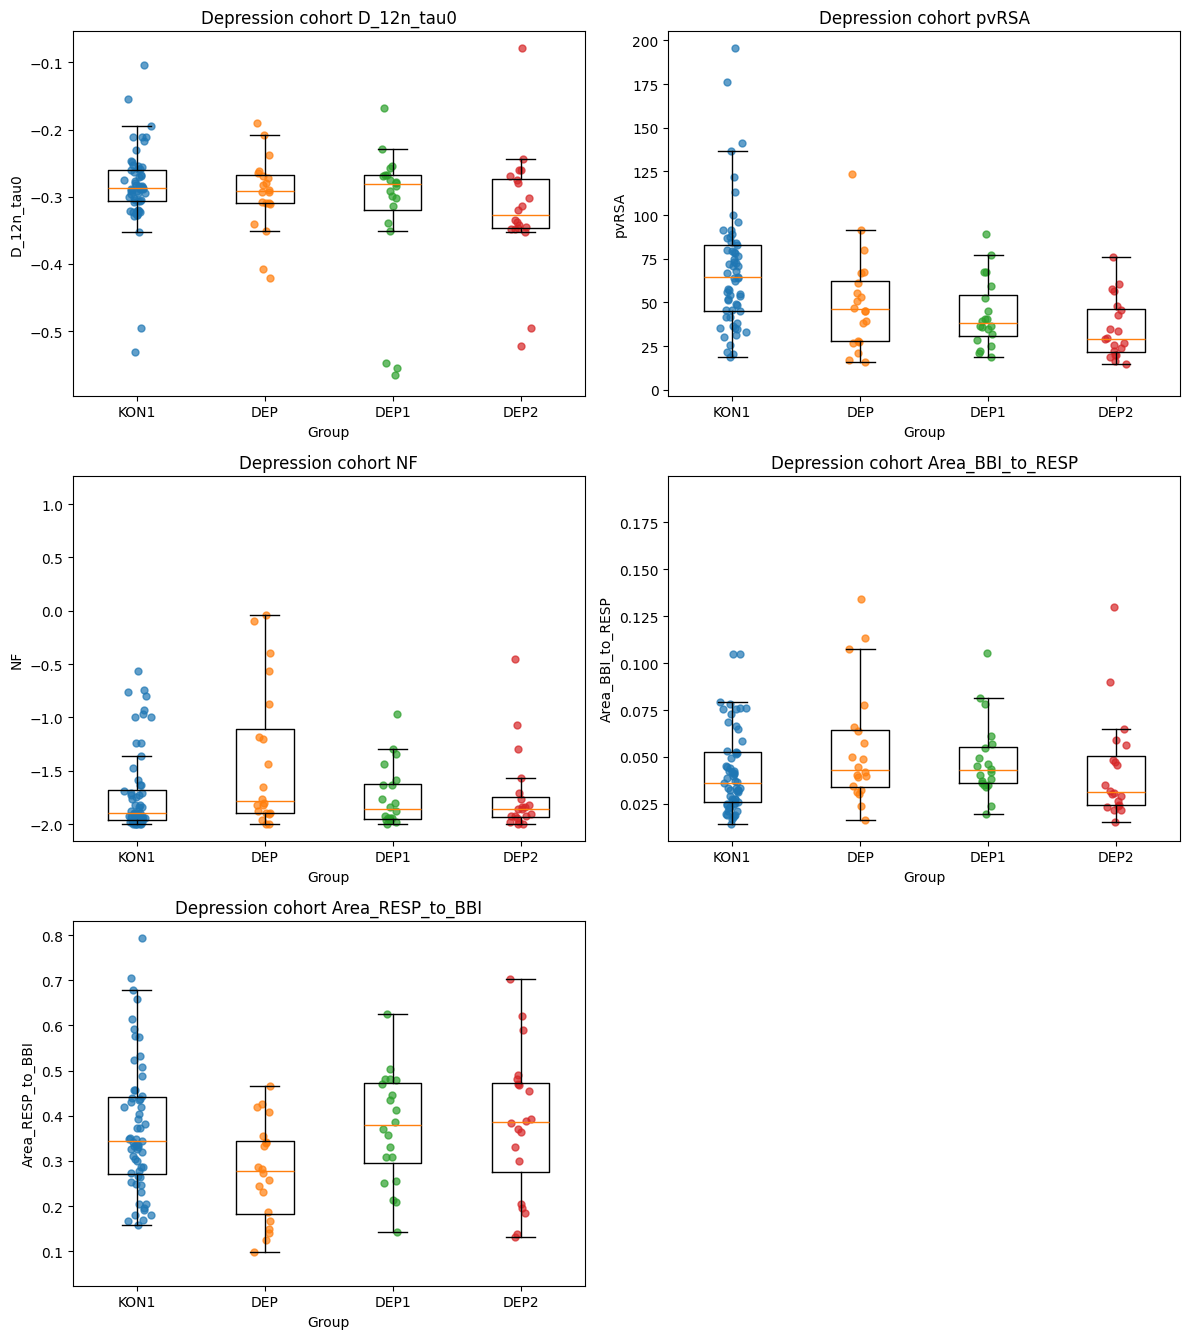

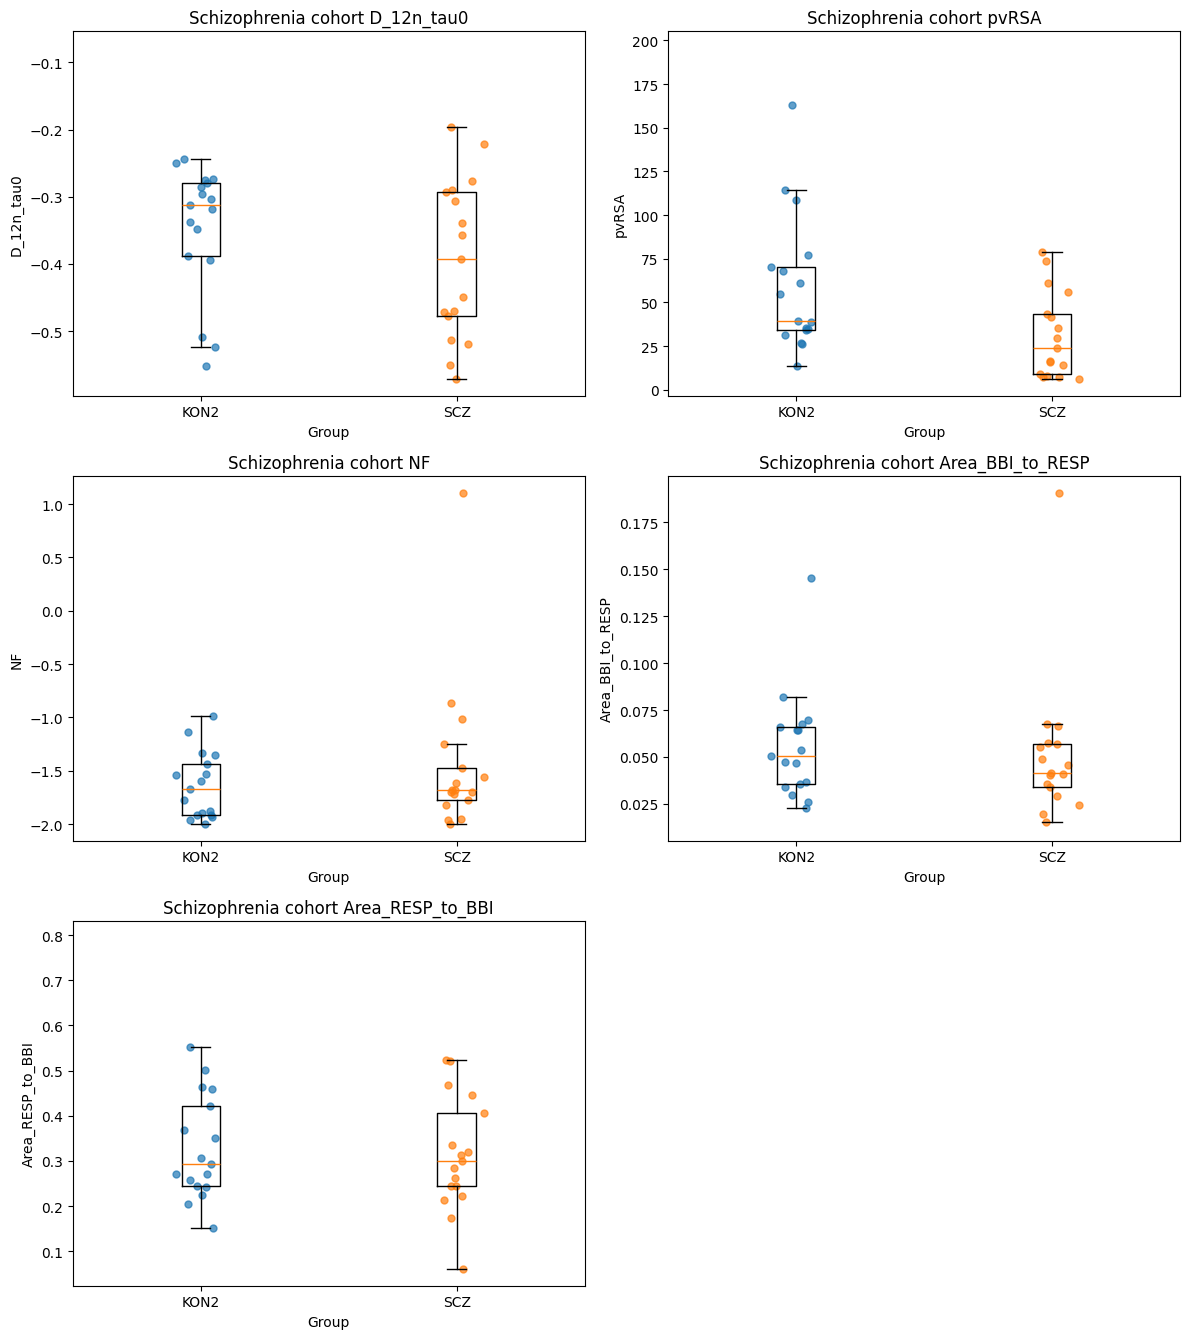

In [24]:
# =========================================================
# 22  Prepare multi panel PDF plots for the main outcomes
# =========================================================

# I define the group orders
dep_group_order = ["KON1", "DEP", "DEP1", "DEP2"]
scz_group_order = ["KON2", "SCZ"]

# I define the main figure variables
main_figure_vars = [
    "D_12n_tau0",
    "pvRSA",
    "NF",
    "Area_BBI_to_RESP",
    "Area_RESP_to_BBI"
]

main_figure_vars = [v for v in main_figure_vars if v in df_physio.columns]

# I calculate shared y axis limits for each variable across all available groups
# This makes depression and schizophrenia figures directly comparable for the same variable
shared_y_limits = {}

for var in main_figure_vars:
    values = df_physio[var].dropna().to_numpy()

    if len(values) == 0:
        shared_y_limits[var] = None
    else:
        y_min = values.min()
        y_max = values.max()

        if y_min == y_max:
            pad = abs(y_min) * 0.05 if y_min != 0 else 0.1
        else:
            pad = (y_max - y_min) * 0.05

        shared_y_limits[var] = (y_min - pad, y_max + pad)

# I define a helper function to draw one boxplot panel with jittered points
def draw_group_boxplot(ax, data, group_col, value_col, group_order, title, y_limits=None):
    plot_df = data[[group_col, value_col]].dropna().copy()

    groups = [
        plot_df.loc[plot_df[group_col] == g, value_col].values
        for g in group_order
    ]

    ax.boxplot(
        groups,
        tick_labels=group_order,
        showfliers=False
    )

    rng = np.random.default_rng(42)

    for i, g in enumerate(group_order, start=1):
        values = plot_df.loc[plot_df[group_col] == g, value_col].values
        jitter = rng.normal(0, 0.05, size=len(values))
        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            alpha=0.7,
            s=25
        )

    ax.set_title(title)
    ax.set_xlabel("Group")
    ax.set_ylabel(value_col)

    if y_limits is not None:
        ax.set_ylim(y_limits)

# I define a function that creates one multi panel figure for one cohort
def save_multi_panel_boxplots(data, group_col, group_order, variables, cohort_name, filename, y_limit_dict):
    n_vars = len(variables)
    n_cols = 2
    n_rows = math.ceil(n_vars / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(variables):
        draw_group_boxplot(
            ax=axes[i],
            data=data,
            group_col=group_col,
            value_col=var,
            group_order=group_order,
            title=f"{cohort_name} cohort {var}",
            y_limits=y_limit_dict.get(var)
        )

    # I remove any unused panels
    for j in range(n_vars, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    fig.savefig(GRAPH_DIR / filename, format="pdf", dpi=300)
    plt.show()

# I prepare the depression cohort data
df_dep_plot = df_physio.loc[df_physio["group_label"].isin(dep_group_order)].copy()

# I prepare the schizophrenia cohort data
df_scz_plot = df_physio.loc[df_physio["group_label"].isin(scz_group_order)].copy()

# I save one combined figure for the depression cohort
save_multi_panel_boxplots(
    data=df_dep_plot,
    group_col="group_label",
    group_order=dep_group_order,
    variables=main_figure_vars,
    cohort_name="Depression",
    filename="dep_main_outcomes.pdf",
    y_limit_dict=shared_y_limits
)

# I save one combined figure for the schizophrenia cohort
save_multi_panel_boxplots(
    data=df_scz_plot,
    group_col="group_label",
    group_order=scz_group_order,
    variables=main_figure_vars,
    cohort_name="Schizophrenia",
    filename="scz_main_outcomes.pdf",
    y_limit_dict=shared_y_limits
)

In [25]:
# =========================================================
# 23  Define focused variables and figure contrasts
# =========================================================

main_figure_vars = [
    "D_12n_tau0",
    "pvRSA",
    "NF",
    "Area_BBI_to_RESP",
    "Area_RESP_to_BBI"
]

main_figure_vars = [v for v in main_figure_vars if v in df_physio.columns]

dep_group_order = ["KON1", "DEP", "DEP1", "DEP2"]
scz_group_order = ["KON2", "SCZ"]

depression_contrasts_for_figures = {
    "KON1_vs_DEP": (["KON1"], ["DEP"]),
    "KON1_vs_DEP1_plus_DEP2": (["KON1"], ["DEP1", "DEP2"]),
    "KON1_vs_DEP1": (["KON1"], ["DEP1"]),
    "KON1_vs_DEP2": (["KON1"], ["DEP2"]),
    "DEP_vs_DEP1": (["DEP"], ["DEP1"]),
    "DEP_vs_DEP2": (["DEP"], ["DEP2"])
}

schizophrenia_contrasts_for_figures = {
    "KON2_vs_SCZ": (["KON2"], ["SCZ"])
}

In [26]:
# =========================================================
# 24  Define helper functions for focused testing
# =========================================================

from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

# I compute one Mann Whitney test for one variable and one planned contrast
def run_pairwise_mannwhitney(data, group_col, value_col, contrast_name, group1_labels, group2_labels):
    sub = data.loc[
        data[group_col].isin(group1_labels + group2_labels),
        [group_col, value_col]
    ].dropna().copy()

    x = sub.loc[sub[group_col].isin(group1_labels), value_col].astype(float)
    y = sub.loc[sub[group_col].isin(group2_labels), value_col].astype(float)

    n1 = len(x)
    n2 = len(y)

    if n1 < 2 or n2 < 2:
        return None

    test_result = mannwhitneyu(x, y, alternative="two-sided", method="auto")
    u_stat = test_result.statistic
    p_value = test_result.pvalue
    r_rank_biserial = (2 * u_stat) / (n1 * n2) - 1

    return {
        "variable": value_col,
        "contrast": contrast_name,
        "group1": ", ".join(group1_labels),
        "group2": ", ".join(group2_labels),
        "n1": n1,
        "n2": n2,
        "median1": x.median(),
        "q1_1": x.quantile(0.25),
        "q3_1": x.quantile(0.75),
        "median2": y.median(),
        "q1_2": y.quantile(0.25),
        "q3_2": y.quantile(0.75),
        "u_stat": u_stat,
        "p_value": p_value,
        "r_rank_biserial": r_rank_biserial
    }

# I run all planned contrasts for a set of variables
# I apply Holm correction within each variable across its planned contrasts
def run_focused_pairwise_tests(data, group_col, variables, contrasts_dict, cohort_name):
    rows = []

    for var in variables:
        for contrast_name, (group1_labels, group2_labels) in contrasts_dict.items():
            row = run_pairwise_mannwhitney(
                data=data,
                group_col=group_col,
                value_col=var,
                contrast_name=contrast_name,
                group1_labels=group1_labels,
                group2_labels=group2_labels
            )

            if row is not None:
                row["cohort"] = cohort_name
                rows.append(row)

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out["p_holm"] = np.nan
    out["significant_holm"] = False

    for var in out["variable"].unique():
        mask = out["variable"] == var
        pvals = out.loc[mask, "p_value"].to_numpy()

        reject, p_holm, _, _ = multipletests(pvals, method="holm")

        out.loc[mask, "p_holm"] = p_holm
        out.loc[mask, "significant_holm"] = reject

    out = out.sort_values(["variable", "p_holm", "p_value", "contrast"]).reset_index(drop=True)
    return out

# I flag whisker outliers within each group and variable
def add_whisker_outlier_flags(data, group_col, variables):
    out = data.copy()

    for var in variables:
        flag_col = f"{var}_is_whisker_outlier"
        out[flag_col] = False

        for group_name, group_df in out.groupby(group_col):
            values = group_df[var].dropna()

            if len(values) < 4:
                continue

            q1 = values.quantile(0.25)
            q3 = values.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            mask = (
                (out[group_col] == group_name) &
                (out[var].notna()) &
                ((out[var] < lower) | (out[var] > upper))
            )

            out.loc[mask, flag_col] = True

    return out

# I remove rows that are whisker outliers for a given variable
def subset_without_whisker_outliers(data, value_col):
    flag_col = f"{value_col}_is_whisker_outlier"

    if flag_col not in data.columns:
        return data.copy()

    return data.loc[~data[flag_col]].copy()

# I add significance stars for plotting
def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n.s."
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "n.s."

In [27]:
# =========================================================
# 25  Create outlier flagged physiology dataset
# =========================================================

df_physio_flagged = add_whisker_outlier_flags(
    data=df_physio,
    group_col="group_label",
    variables=main_figure_vars
)

# I create a small overview of how many whisker outliers exist per variable
whisker_outlier_summary = []

for var in main_figure_vars:
    flag_col = f"{var}_is_whisker_outlier"

    whisker_outlier_summary.append({
        "variable": var,
        "n_outliers": int(df_physio_flagged[flag_col].sum())
    })

whisker_outlier_summary = pd.DataFrame(whisker_outlier_summary)
display(whisker_outlier_summary)

whisker_outlier_summary.to_excel(BASE_DIR / "physio_whisker_outlier_summary.xlsx", index=False)

,variable,n_outliers
0,D_12n_tau0,15
1,pvRSA,6
2,NF,17
3,Area_BBI_to_RESP,9
4,Area_RESP_to_BBI,2


In [28]:
# =========================================================
# 26  Run focused pairwise tests for the main outcomes
# =========================================================

# I define the cohort specific subsets
df_dep_main = df_physio_flagged.loc[df_physio_flagged["group_label"].isin(dep_group_order)].copy()
df_scz_main = df_physio_flagged.loc[df_physio_flagged["group_label"].isin(scz_group_order)].copy()

# I run the primary analyses with all data
results_dep_main_all = run_focused_pairwise_tests(
    data=df_dep_main,
    group_col="group_label",
    variables=main_figure_vars,
    contrasts_dict=depression_contrasts_for_figures,
    cohort_name="Depression"
)

results_scz_main_all = run_focused_pairwise_tests(
    data=df_scz_main,
    group_col="group_label",
    variables=main_figure_vars,
    contrasts_dict=schizophrenia_contrasts_for_figures,
    cohort_name="Schizophrenia"
)

results_main_all = pd.concat(
    [results_dep_main_all, results_scz_main_all],
    ignore_index=True
)

# I run the sensitivity analyses without whisker outliers
results_dep_main_no_outliers = []
for var in main_figure_vars:
    tmp = subset_without_whisker_outliers(df_dep_main, var)

    tmp_result = run_focused_pairwise_tests(
        data=tmp,
        group_col="group_label",
        variables=[var],
        contrasts_dict=depression_contrasts_for_figures,
        cohort_name="Depression"
    )

    results_dep_main_no_outliers.append(tmp_result)

results_dep_main_no_outliers = pd.concat(results_dep_main_no_outliers, ignore_index=True)

results_scz_main_no_outliers = []
for var in main_figure_vars:
    tmp = subset_without_whisker_outliers(df_scz_main, var)

    tmp_result = run_focused_pairwise_tests(
        data=tmp,
        group_col="group_label",
        variables=[var],
        contrasts_dict=schizophrenia_contrasts_for_figures,
        cohort_name="Schizophrenia"
    )

    results_scz_main_no_outliers.append(tmp_result)

results_scz_main_no_outliers = pd.concat(results_scz_main_no_outliers, ignore_index=True)

results_main_no_outliers = pd.concat(
    [results_dep_main_no_outliers, results_scz_main_no_outliers],
    ignore_index=True
)

results_main_all_rounded = round_output_table(results_main_all, digits=3)
results_main_no_outliers_rounded = round_output_table(results_main_no_outliers, digits=3)

display(results_main_all_rounded)
display(results_main_no_outliers_rounded)

results_main_all_rounded.to_excel(BASE_DIR / "results_main_outcomes_all_data.xlsx", index=False)
results_main_no_outliers_rounded.to_excel(BASE_DIR / "results_main_outcomes_no_whisker_outliers.xlsx", index=False)

,variable,contrast,group1,group2,n1,n2,median1,q1_1,q3_1,median2,q1_2,q3_2,u_stat,p_value,r_rank_biserial,cohort,p_holm,significant_holm
0,Area_BBI_to_RESP,DEP_vs_DEP2,DEP,DEP2,20,20,0.043,0.034,0.064,0.032,0.024,0.051,264.0,0.086,0.320,Depression,0.515,False
1,Area_BBI_to_RESP,KON1_vs_DEP,KON1,DEP,60,20,0.036,0.026,0.052,0.043,0.034,0.064,448.0,0.092,-0.253,Depression,0.515,False
2,Area_BBI_to_RESP,KON1_vs_DEP1,KON1,DEP1,60,20,0.036,0.026,0.052,0.043,0.036,0.055,448.0,0.092,-0.253,Depression,0.515,False
3,Area_BBI_to_RESP,KON1_vs_DEP1_plus_DEP2,KON1,"DEP1, DEP2",60,40,0.036,0.026,0.052,0.039,0.030,0.055,1079.0,0.397,-0.101,Depression,1.000,False
4,Area_BBI_to_RESP,KON1_vs_DEP2,KON1,DEP2,60,20,0.036,0.026,0.052,0.032,0.024,0.051,631.0,0.735,0.052,Depression,1.000,False
5,Area_BBI_to_RESP,DEP_vs_DEP1,DEP,DEP1,20,20,0.043,0.034,0.064,0.043,0.036,0.055,209.0,0.818,0.045,Depression,1.000,False
6,Area_RESP_to_BBI,KON1_vs_DEP,KON1,DEP,60,20,0.344,0.271,0.441,0.278,0.182,0.344,822.0,0.014,0.370,Depression,0.083,False
7,Area_RESP_to_BBI,DEP_vs_DEP1,DEP,DEP1,20,20,0.278,0.182,0.344,0.379,0.295,0.473,110.0,0.015,-0.450,Depression,0.083,False
8,Area_RESP_to_BBI,DEP_vs_DEP2,DEP,DEP2,20,20,0.278,0.182,0.344,0.386,0.276,0.473,116.0,0.024,-0.420,Depression,0.096,False
9,Area_RESP_to_BBI,KON1_vs_DEP1_plus_DEP2,KON1,"DEP1, DEP2",60,40,0.344,0.271,0.441,0.386,0.289,0.473,1108.0,0.520,-0.077,Depression,1.000,False


,variable,contrast,group1,group2,n1,n2,median1,q1_1,q3_1,median2,q1_2,q3_2,u_stat,p_value,r_rank_biserial,cohort,p_holm,significant_holm
0,D_12n_tau0,KON1_vs_DEP2,KON1,DEP2,56,17,-0.287,-0.306,-0.262,-0.319,-0.345,-0.274,658.0,0.018,0.382,Depression,0.107,False
1,D_12n_tau0,DEP_vs_DEP2,DEP,DEP2,17,17,-0.290,-0.309,-0.269,-0.319,-0.345,-0.274,191.0,0.113,0.322,Depression,0.566,False
2,D_12n_tau0,KON1_vs_DEP1_plus_DEP2,KON1,"DEP1, DEP2",56,33,-0.287,-0.306,-0.262,-0.292,-0.338,-0.269,1078.0,0.192,0.167,Depression,0.769,False
3,D_12n_tau0,DEP_vs_DEP1,DEP,DEP1,17,16,-0.290,-0.309,-0.269,-0.279,-0.299,-0.268,123.0,0.653,-0.096,Depression,1.000,False
4,D_12n_tau0,KON1_vs_DEP1,KON1,DEP1,56,16,-0.287,-0.306,-0.262,-0.279,-0.299,-0.268,420.0,0.710,-0.062,Depression,1.000,False
5,D_12n_tau0,KON1_vs_DEP,KON1,DEP,56,17,-0.287,-0.306,-0.262,-0.290,-0.309,-0.269,505.0,0.710,0.061,Depression,1.000,False
6,pvRSA,KON1_vs_DEP1_plus_DEP2,KON1,"DEP1, DEP2",57,39,63.850,44.850,79.400,34.870,24.430,46.840,1763.0,0.000,0.586,Depression,0.000,True
7,pvRSA,KON1_vs_DEP2,KON1,DEP2,57,20,63.850,44.850,79.400,29.360,21.585,46.395,939.0,0.000,0.647,Depression,0.000,True
8,pvRSA,KON1_vs_DEP1,KON1,DEP1,57,19,63.850,44.850,79.400,36.580,30.070,48.825,824.0,0.001,0.522,Depression,0.003,True
9,pvRSA,KON1_vs_DEP,KON1,DEP,57,19,63.850,44.850,79.400,45.340,27.615,58.120,750.0,0.013,0.385,Depression,0.038,True


In [29]:
# =========================================================
# 27  Compare primary and sensitivity results
# =========================================================

comparison_main = results_main_all.merge(
    results_main_no_outliers,
    on=["cohort", "variable", "contrast", "group1", "group2"],
    how="outer",
    suffixes=("_all", "_no_outliers")
)

comparison_main["same_significance_holm"] = (
    comparison_main["significant_holm_all"] == comparison_main["significant_holm_no_outliers"]
)

comparison_main_rounded = round_output_table(comparison_main, digits=3)

display(comparison_main_rounded)

comparison_main_rounded.to_excel(BASE_DIR / "results_main_outcomes_primary_vs_sensitivity.xlsx", index=False)

,variable,contrast,group1,group2,n1_all,n2_all,median1_all,q1_1_all,q3_1_all,median2_all,q1_2_all,q3_2_all,u_stat_all,p_value_all,r_rank_biserial_all,cohort,p_holm_all,significant_holm_all,n1_no_outliers,n2_no_outliers,median1_no_outliers,q1_1_no_outliers,q3_1_no_outliers,median2_no_outliers,q1_2_no_outliers,q3_2_no_outliers,u_stat_no_outliers,p_value_no_outliers,r_rank_biserial_no_outliers,p_holm_no_outliers,significant_holm_no_outliers,same_significance_holm
0,Area_BBI_to_RESP,DEP_vs_DEP1,DEP,DEP1,20,20,0.043,0.034,0.064,0.043,0.036,0.055,209.0,0.818,0.045,Depression,1.000,False,18,19,0.041,0.033,0.056,0.042,0.036,0.052,168.0,0.939,-0.018,1.000,False,True
1,Area_BBI_to_RESP,DEP_vs_DEP2,DEP,DEP2,20,20,0.043,0.034,0.064,0.032,0.024,0.051,264.0,0.086,0.320,Depression,0.515,False,18,18,0.041,0.033,0.056,0.031,0.024,0.047,224.0,0.052,0.383,0.310,False,True
2,Area_BBI_to_RESP,KON1_vs_DEP,KON1,DEP,60,20,0.036,0.026,0.052,0.043,0.034,0.064,448.0,0.092,-0.253,Depression,0.515,False,58,18,0.035,0.026,0.051,0.041,0.033,0.056,414.0,0.189,-0.207,0.756,False,True
3,Area_BBI_to_RESP,KON1_vs_DEP1,KON1,DEP1,60,20,0.036,0.026,0.052,0.043,0.036,0.055,448.0,0.092,-0.253,Depression,0.515,False,58,19,0.035,0.026,0.051,0.042,0.036,0.052,410.0,0.097,-0.256,0.484,False,True
4,Area_BBI_to_RESP,KON1_vs_DEP1_plus_DEP2,KON1,"DEP1, DEP2",60,40,0.036,0.026,0.052,0.039,0.030,0.055,1079.0,0.397,-0.101,Depression,1.000,False,58,37,0.035,0.026,0.051,0.037,0.029,0.049,1003.0,0.596,-0.065,1.000,False,True
5,Area_BBI_to_RESP,KON1_vs_DEP2,KON1,DEP2,60,20,0.036,0.026,0.052,0.032,0.024,0.051,631.0,0.735,0.052,Depression,1.000,False,58,18,0.035,0.026,0.051,0.031,0.024,0.047,593.0,0.389,0.136,1.000,False,True
6,Area_RESP_to_BBI,DEP_vs_DEP1,DEP,DEP1,20,20,0.278,0.182,0.344,0.379,0.295,0.473,110.0,0.015,-0.450,Depression,0.083,False,20,20,0.278,0.182,0.344,0.379,0.295,0.473,110.0,0.015,-0.450,0.093,False,True
7,Area_RESP_to_BBI,DEP_vs_DEP2,DEP,DEP2,20,20,0.278,0.182,0.344,0.386,0.276,0.473,116.0,0.024,-0.420,Depression,0.096,False,20,20,0.278,0.182,0.344,0.386,0.276,0.473,116.0,0.024,-0.420,0.106,False,True
8,Area_RESP_to_BBI,KON1_vs_DEP,KON1,DEP,60,20,0.344,0.271,0.441,0.278,0.182,0.344,822.0,0.014,0.370,Depression,0.083,False,58,20,0.339,0.268,0.437,0.278,0.182,0.344,782.0,0.021,0.348,0.106,False,True
9,Area_RESP_to_BBI,KON1_vs_DEP1,KON1,DEP1,60,20,0.344,0.271,0.441,0.379,0.295,0.473,560.0,0.661,-0.067,Depression,1.000,False,58,20,0.339,0.268,0.437,0.379,0.295,0.473,520.0,0.496,-0.103,1.000,False,True


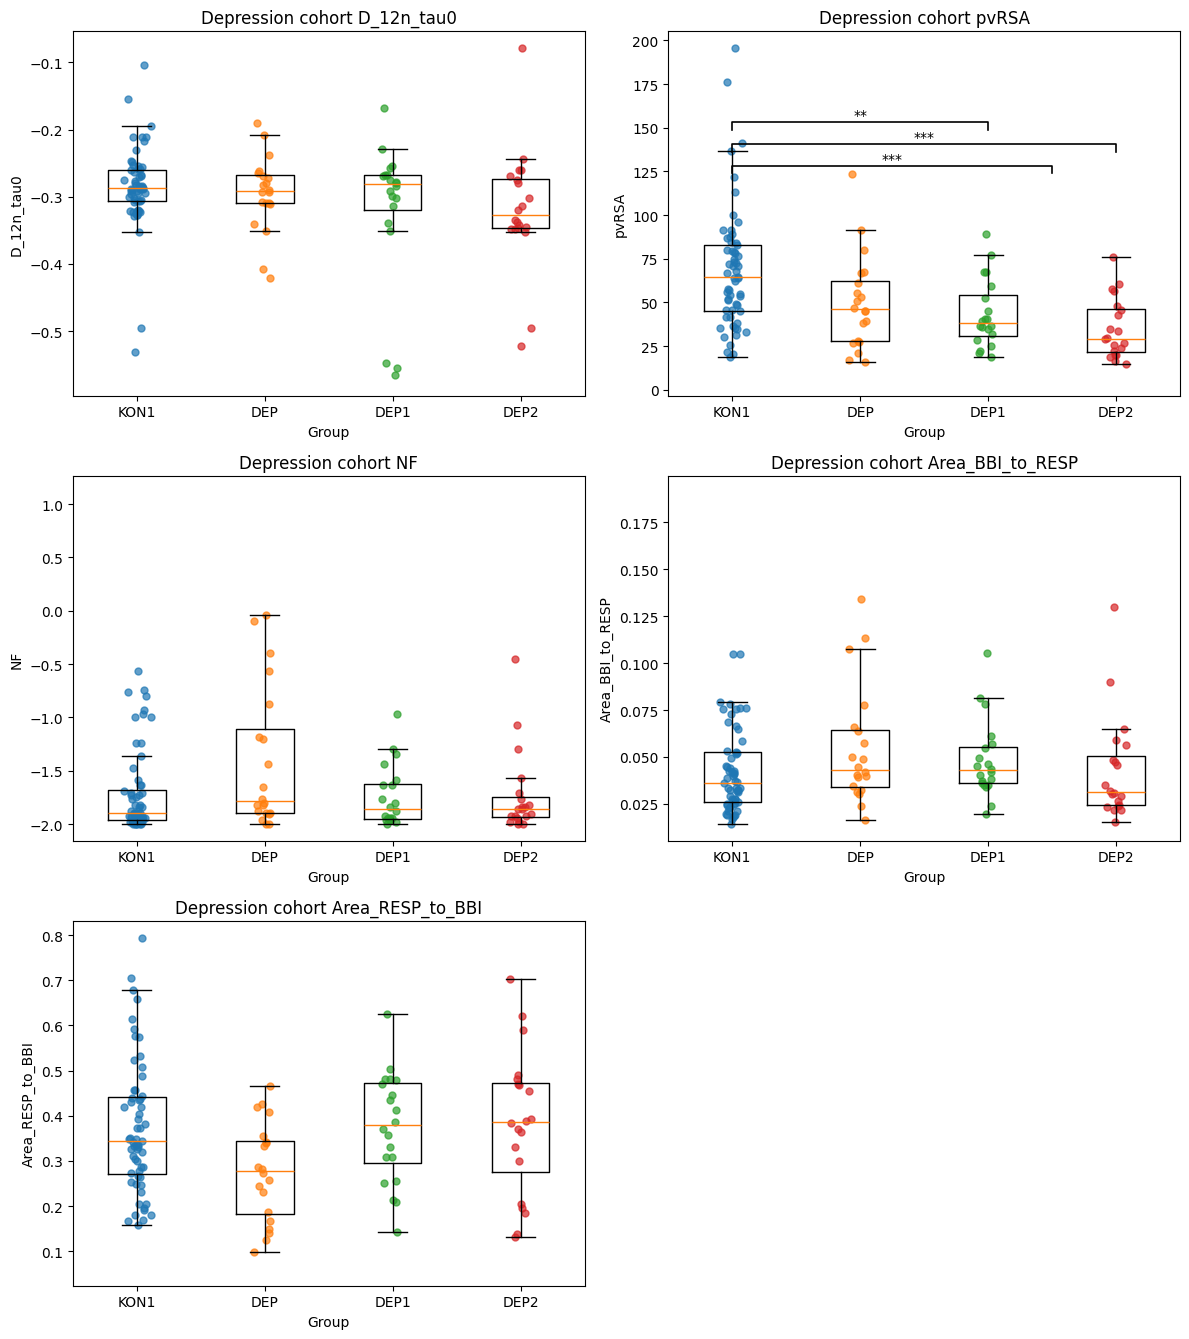

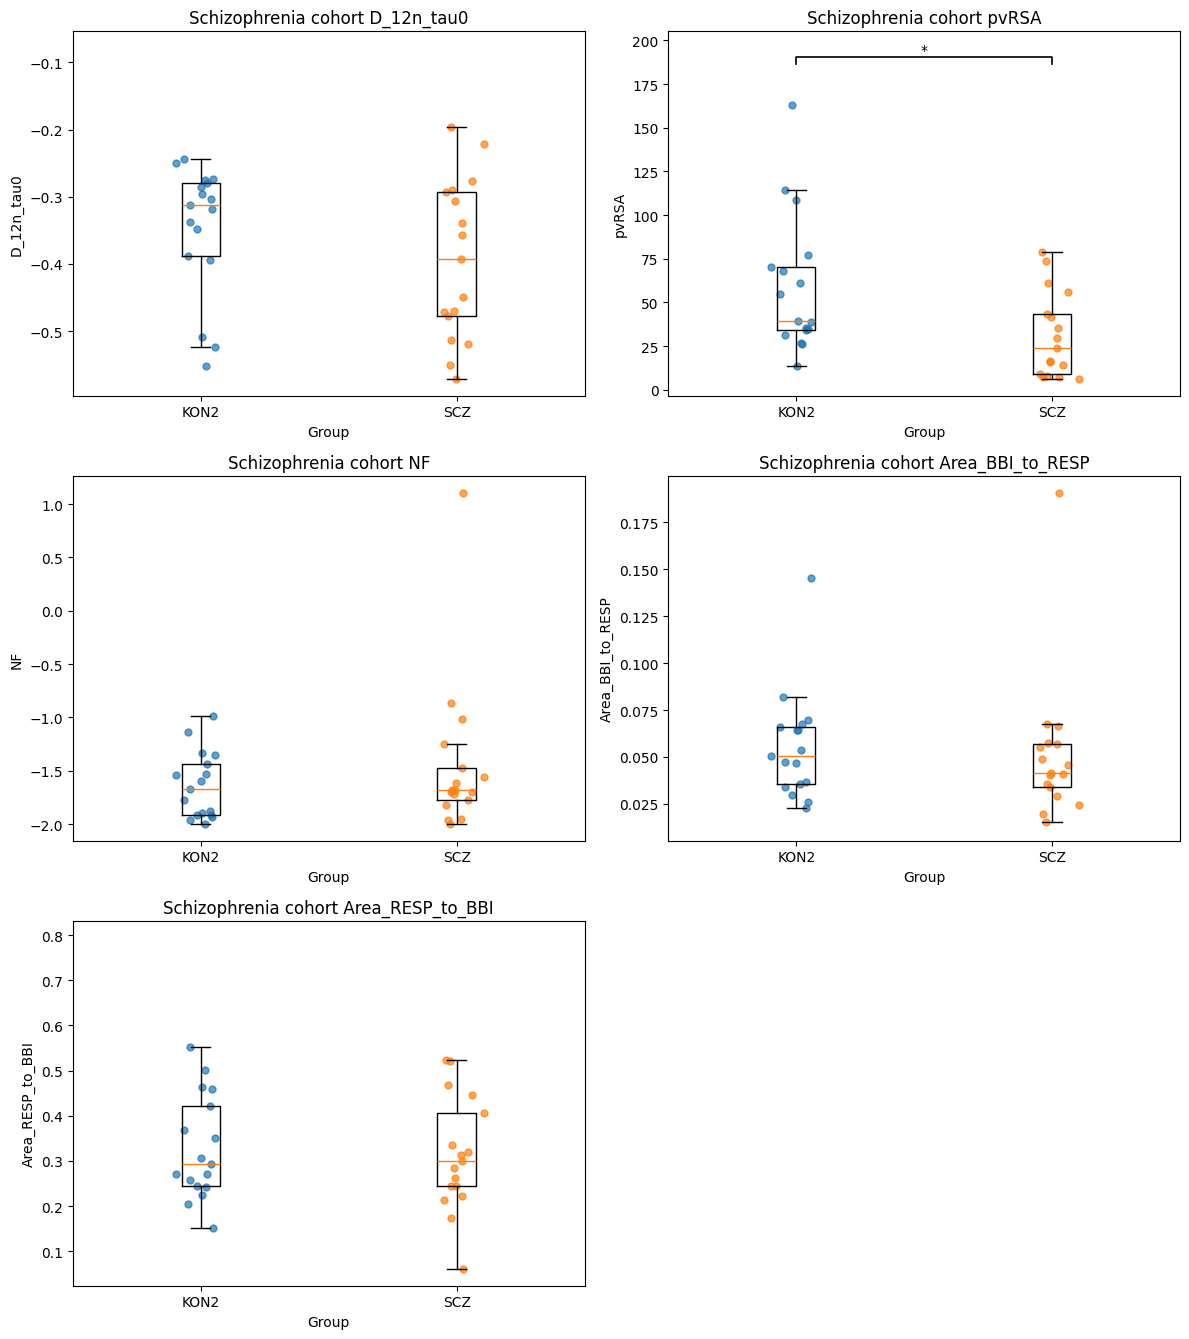

In [30]:
# =========================================================
# 28  Add significance brackets to the boxplots
# =========================================================

# I define where each contrast sits on the x axis for the figure panels
dep_contrast_positions = {
    "KON1_vs_DEP": (1, 2),
    "KON1_vs_DEP1_plus_DEP2": (1, 3.5),
    "KON1_vs_DEP1": (1, 3),
    "KON1_vs_DEP2": (1, 4),
    "DEP_vs_DEP1": (2, 3),
    "DEP_vs_DEP2": (2, 4)
}

scz_contrast_positions = {
    "KON2_vs_SCZ": (1, 2)
}

# I draw one significance bracket
def add_significance_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=10)

# I draw one boxplot panel with optional significance annotations
def draw_group_boxplot_with_stats(
    ax,
    data,
    group_col,
    value_col,
    group_order,
    title,
    y_limits=None,
    stats_df=None,
    contrast_positions=None,
    annotate_only_significant=False
):
    plot_df = data[[group_col, value_col]].dropna().copy()

    groups = [
        plot_df.loc[plot_df[group_col] == g, value_col].values
        for g in group_order
    ]

    ax.boxplot(
        groups,
        tick_labels=group_order,
        showfliers=False
    )

    rng = np.random.default_rng(42)

    for i, g in enumerate(group_order, start=1):
        values = plot_df.loc[plot_df[group_col] == g, value_col].values
        jitter = rng.normal(0, 0.05, size=len(values))
        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            alpha=0.7,
            s=25
        )

    ax.set_title(title)
    ax.set_xlabel("Group")
    ax.set_ylabel(value_col)

    if y_limits is not None:
        ax.set_ylim(y_limits)

    if stats_df is not None and contrast_positions is not None:
        tmp_stats = stats_df.loc[stats_df["variable"] == value_col].copy()

        if len(tmp_stats) > 0:
            y0, y1 = ax.get_ylim()
            y_range = y1 - y0
            step = y_range * 0.06
            h = y_range * 0.02
            current_y = y1 - (step * (len(tmp_stats) + 0.5))

            for _, row in tmp_stats.iterrows():
                contrast_name = row["contrast"]

                if contrast_name not in contrast_positions:
                    continue

                if annotate_only_significant and not bool(row["significant_holm"]):
                    continue

                x1, x2 = contrast_positions[contrast_name]
                label = p_to_stars(row["p_holm"])

                add_significance_bracket(
                    ax=ax,
                    x1=x1,
                    x2=x2,
                    y=current_y,
                    h=h,
                    text=label
                )

                current_y += step

# I create one multi panel figure with significance annotations
def save_multi_panel_boxplots_with_stats(
    data,
    group_col,
    group_order,
    variables,
    cohort_name,
    filename,
    y_limit_dict,
    stats_df,
    contrast_positions,
    annotate_only_significant=False
):
    n_vars = len(variables)
    n_cols = 2
    n_rows = math.ceil(n_vars / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(variables):
        draw_group_boxplot_with_stats(
            ax=axes[i],
            data=data,
            group_col=group_col,
            value_col=var,
            group_order=group_order,
            title=f"{cohort_name} cohort {var}",
            y_limits=y_limit_dict.get(var),
            stats_df=stats_df,
            contrast_positions=contrast_positions,
            annotate_only_significant=annotate_only_significant
        )

    for j in range(n_vars, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    fig.savefig(GRAPH_DIR / filename, format="pdf", dpi=300)
    plt.show()

# I plot the primary figures with Holm corrected significance
save_multi_panel_boxplots_with_stats(
    data=df_dep_main,
    group_col="group_label",
    group_order=dep_group_order,
    variables=main_figure_vars,
    cohort_name="Depression",
    filename="dep_main_outcomes_with_stats.pdf",
    y_limit_dict=shared_y_limits,
    stats_df=results_dep_main_all,
    contrast_positions=dep_contrast_positions,
    annotate_only_significant=True
)

save_multi_panel_boxplots_with_stats(
    data=df_scz_main,
    group_col="group_label",
    group_order=scz_group_order,
    variables=main_figure_vars,
    cohort_name="Schizophrenia",
    filename="scz_main_outcomes_with_stats.pdf",
    y_limit_dict=shared_y_limits,
    stats_df=results_scz_main_all,
    contrast_positions=scz_contrast_positions,
    annotate_only_significant=True
)

In [31]:
# =========================================================
# 29  Run the prespecified correlations as primary and sensitivity analyses
# =========================================================

corr_pairs_physio = [
    ("D_12n_tau0", "pvRSA"),
    ("D_12n_tau0", "NF"),
    ("D_12n_tau0", "Area_BBI_to_RESP"),
    ("D_12n_tau0", "Area_RESP_to_BBI")
]

# I run the primary correlations with all data
corr_dep_all = run_spearman_pairs(
    data=df_dep_main,
    pairs=corr_pairs_physio,
    subset_groups=None,
    group_col="group_label"
)
corr_dep_all["cohort"] = "Depression"
corr_dep_all["analysis"] = "all_data"

corr_scz_all = run_spearman_pairs(
    data=df_scz_main,
    pairs=corr_pairs_physio,
    subset_groups=None,
    group_col="group_label"
)
corr_scz_all["cohort"] = "Schizophrenia"
corr_scz_all["analysis"] = "all_data"

# I run the sensitivity correlations without whisker outliers in either variable of the pair
corr_sensitivity_rows = []

for cohort_name, cohort_df in [("Depression", df_dep_main), ("Schizophrenia", df_scz_main)]:
    for x_var, y_var in corr_pairs_physio:
        tmp = cohort_df.copy()

        x_flag = f"{x_var}_is_whisker_outlier"
        y_flag = f"{y_var}_is_whisker_outlier"

        if x_flag in tmp.columns:
            tmp = tmp.loc[~tmp[x_flag]].copy()
        if y_flag in tmp.columns:
            tmp = tmp.loc[~tmp[y_flag]].copy()

        tmp2 = tmp[[x_var, y_var]].dropna().copy()
        n = len(tmp2)

        if n < 3:
            rho = np.nan
            p_value = np.nan
        else:
            rho, p_value = spearmanr(tmp2[x_var], tmp2[y_var], nan_policy="omit")

        corr_sensitivity_rows.append({
            "subset": "all",
            "x_var": x_var,
            "y_var": y_var,
            "n": n,
            "rho": rho,
            "p_value": p_value,
            "cohort": cohort_name,
            "analysis": "no_whisker_outliers"
        })

corr_sensitivity = pd.DataFrame(corr_sensitivity_rows)

for cohort_name in corr_sensitivity["cohort"].unique():
    mask = (corr_sensitivity["cohort"] == cohort_name) & corr_sensitivity["p_value"].notna()
    if mask.sum() > 0:
        reject, p_holm, _, _ = multipletests(corr_sensitivity.loc[mask, "p_value"], method="holm")
        corr_sensitivity.loc[mask, "p_holm"] = p_holm
        corr_sensitivity.loc[mask, "significant_holm"] = reject

corr_primary = pd.concat([corr_dep_all, corr_scz_all], ignore_index=True)
corr_all_versions = pd.concat([corr_primary, corr_sensitivity], ignore_index=True)

corr_all_versions_rounded = round_output_table(corr_all_versions, digits=3)
display(corr_all_versions_rounded)

corr_all_versions_rounded.to_excel(BASE_DIR / "correlations_main_outcomes_primary_and_sensitivity.xlsx", index=False)

,subset,x_var,y_var,n,rho,p_value,p_holm,significant_holm,cohort,analysis
0,all,D_12n_tau0,pvRSA,120,0.120,0.193,0.270,False,Depression,all_data
1,all,D_12n_tau0,NF,120,0.137,0.135,0.270,False,Depression,all_data
2,all,D_12n_tau0,Area_BBI_to_RESP,120,0.239,0.009,0.035,True,Depression,all_data
3,all,D_12n_tau0,Area_RESP_to_BBI,120,0.193,0.035,0.105,False,Depression,all_data
4,all,D_12n_tau0,pvRSA,34,0.168,0.343,1.000,False,Schizophrenia,all_data
5,all,D_12n_tau0,NF,34,0.046,0.795,1.000,False,Schizophrenia,all_data
6,all,D_12n_tau0,Area_BBI_to_RESP,34,0.121,0.496,1.000,False,Schizophrenia,all_data
7,all,D_12n_tau0,Area_RESP_to_BBI,34,0.149,0.400,1.000,False,Schizophrenia,all_data
8,all,D_12n_tau0,pvRSA,102,-0.031,0.760,0.760,False,Depression,no_whisker_outliers
9,all,D_12n_tau0,NF,96,0.177,0.085,0.255,False,Depression,no_whisker_outliers


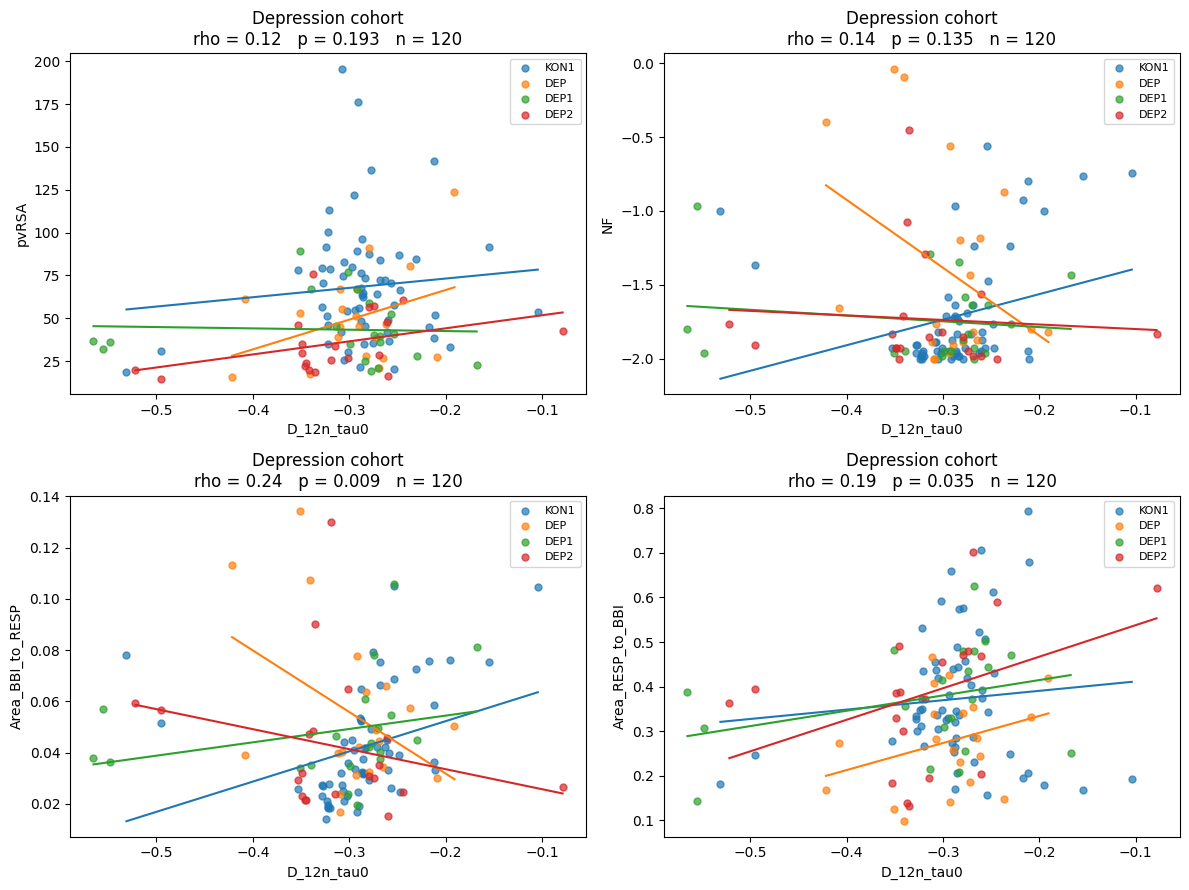

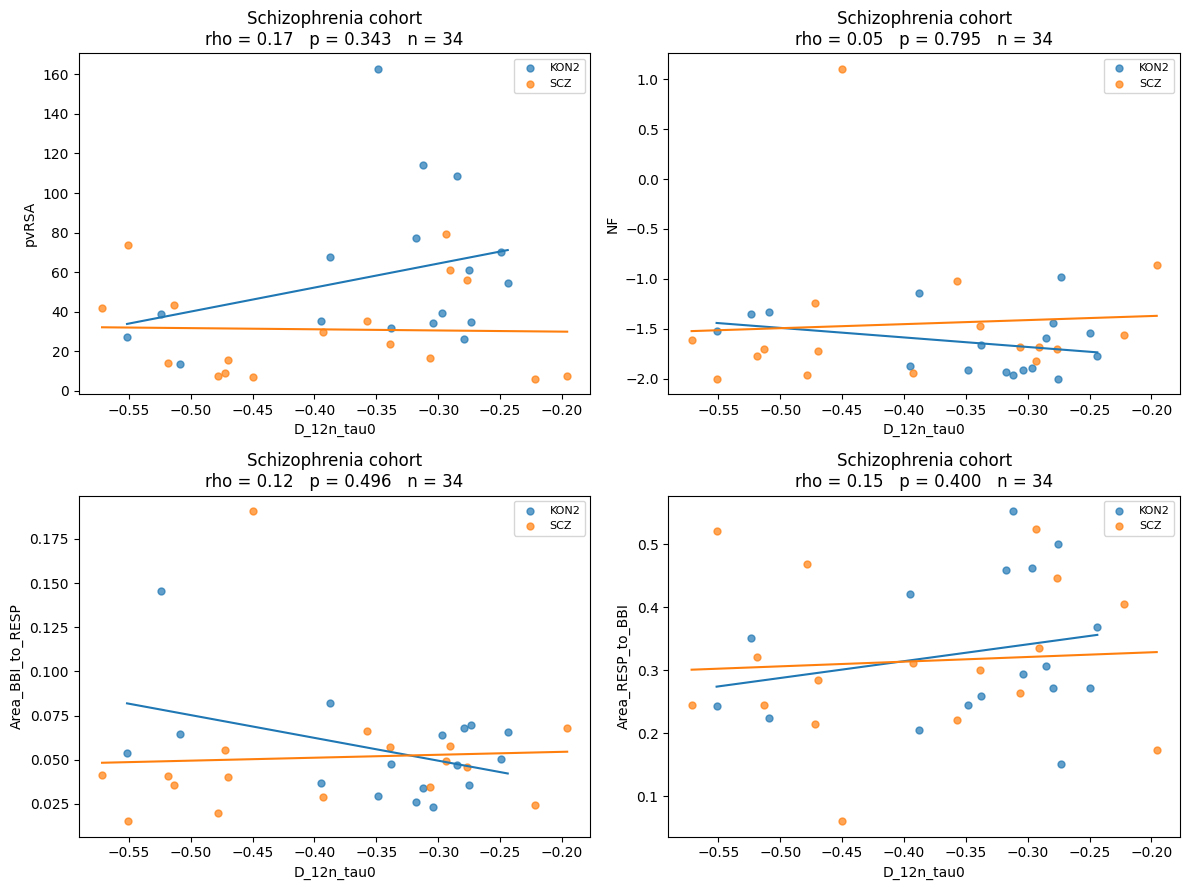

In [32]:
# =========================================================
# 30  Plot the correlation scatter plots with group specific lines
# =========================================================

# I draw a simple fitted line for visualisation
def add_group_fit_line(ax, x, y):
    if len(x) < 2:
        return

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if np.unique(x).shape[0] < 2:
        return

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, linewidth=1.5)

# I create one scatter panel
def draw_correlation_panel(ax, data, x_var, y_var, group_col, group_order, title):
    tmp = data[[group_col, x_var, y_var]].dropna().copy()

    for group_name in group_order:
        sub = tmp.loc[tmp[group_col] == group_name].copy()

        ax.scatter(sub[x_var], sub[y_var], alpha=0.7, s=25, label=group_name)

        if len(sub) >= 3:
            add_group_fit_line(ax, sub[x_var], sub[y_var])

    if len(tmp) >= 3:
        rho, p_value = spearmanr(tmp[x_var], tmp[y_var], nan_policy="omit")
        subtitle = f"rho = {rho:.2f}   p = {p_value:.3f}   n = {len(tmp)}"
    else:
        subtitle = f"n = {len(tmp)}"

    ax.set_title(f"{title}\n{subtitle}")
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.legend(fontsize=8)

# I save one multi panel correlation figure
def save_correlation_figure(data, pairs, group_col, group_order, cohort_name, filename):
    n_pairs = len(pairs)
    n_cols = 2
    n_rows = math.ceil(n_pairs / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, (x_var, y_var) in enumerate(pairs):
        draw_correlation_panel(
            ax=axes[i],
            data=data,
            x_var=x_var,
            y_var=y_var,
            group_col=group_col,
            group_order=group_order,
            title=f"{cohort_name} cohort"
        )

    for j in range(n_pairs, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    fig.savefig(GRAPH_DIR / filename, format="pdf", dpi=300)
    plt.show()

save_correlation_figure(
    data=df_dep_main,
    pairs=corr_pairs_physio,
    group_col="group_label",
    group_order=dep_group_order,
    cohort_name="Depression",
    filename="dep_correlations_main_outcomes.pdf"
)

save_correlation_figure(
    data=df_scz_main,
    pairs=corr_pairs_physio,
    group_col="group_label",
    group_order=scz_group_order,
    cohort_name="Schizophrenia",
    filename="scz_correlations_main_outcomes.pdf"
)